In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from autogluon.tabular import TabularPredictor
from sbpy.data import Names
import json
from scipy.stats import poisson
from sklearn.metrics import mean_poisson_deviance, mean_tweedie_deviance
from autogluon.core.metrics import make_scorer
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

import datetime

import activityscope_utils as utils
import os
import tempfile

In [2]:
# PARAMETERS

# We are doing >= 4 opps as the positive class in the binary classification example
NUM_OPPS_FOR_TRAINING = 4

# Training filters (less than this and we don't trust the orbit)
MIN_ARC_LENGTH_FOR_TRAINING = 20
MIN_NUM_OBS_FOR_TRAINING = 16

# Total training time limit (seconds), don't set below 500, but potentially go up to two hours for maximum performance
TRAINING_TIME_LIMIT = 500

# Load known active objects and dual designation list from JSON files
# This is NOT used in any way to bias the model results, and if you remove it, the model will still behave overall in roughly the same way.
# Excluding them may improve model performance by reducing noise in the training data, and may allow the next layer of discoveries to emerge more clearly.
with open('known_active_objects.json', 'r') as f:
    known_strongly_suspected_active_objects = json.load(f)

# MPC lists these as (2060) for example and pandas makes that a negative number. We are removing dual asteroid comet designations from the training set.
with open('dual_designation_list.json', 'r') as f:
    dual_designation_list = json.load(f)

# Bringing in Orbit Database, Do Feature Engineering, and Specific Fixes/Filters on it


The `utils.load_all_databases()` function performs comprehensive database loading and initial processing.

**Database Loading:**

- Loads MPC (Minor Planet Center) orbit database from `mpcorb_extended.json.gz

- Creates `Is_Past_Threshold` binary classification target (>= 4 oppositions). Creates `Num_opps_minus_one` regression target (additional oppositions beyond the first) which is the regression target.

- Loads astrometry counts from local JSON file and merges with MPC data. These astrometry counts can be generated using the astrometry_counter.ipynb notebook.

- Loads AstDyS multi-opposition and single-opposition catalogs

- Loads JPL (Jet Propulsion Laboratory) unnumbered objects database

- `filter out unless updated.csv` - objects excluded unless orbit has been updated (arc length changed)

- `filter until further notice.csv` - objects excluded until removed from the file

**Database Cross-Comparison:**

- Applies filter lists to exclude problematic objects:

- Compares MPC orbits with AstDyS to identify multi-opposition discrepancies- Applies magnitude corrections from `absolute magnitude fixes.csv` for objects with known photometry issues

- Compares MPC orbits with JPL for independent verification

**Data Quality Corrections:**

- Computes absolute differences in orbital elements (H magnitude, semi-major axis a, eccentricity e, inclination i) between MPC and AstDyS

- Computes H magnitude differences with JPL- Sets final H magnitude to the **dimmest** (most conservative) value across all three databases


The `utils.feature_engineering()` function then adds **visibility metrics** (apparent magnitudes at various orbital configurations), **orbital dynamics features** (Tisserand parameter, resonances, Trojan classification), and **geometric features** (perihelion direction vectors, declination, galactic plane alignment).

In [3]:
orb = utils.load_all_databases(apply_filters=True)
orb = utils.feature_engineering(orb)

Loading MPC orbits...
Loading astrometry counts...
Loading AstDyS orbits...
Loaded 551745 AstDyS orbits
Loading JPL orbits...
Comparing with AstDyS...
Comparing with JPL...
Computing database differences...
Applying magnitude corrections...
Adding training targets...


# Filtering


After database loading and feature engineering, we apply additional filters to create a high-quality training set. These filters ensure the training data consists of well-observed, reliably linked objects with concordant orbital elements across independent databases.


**Extension Difficulty Filter:**

- Excludes dual asteroid-comet designations (e.g., 2060 Chiron = 95P/Chiron)

- Merges pre-computed `extension_difficulty` metric (probability an orbit linkage is incorrect)

- Excludes known active objects (model should reflect inert asteroid population)

- MPC uncertainty parameter U < 9 (well-determined orbits)

- Extension difficulty < 0.1 (this metric is described below where it is regenerated from scratch). This functionally gets rid of many mislinkages and short arcs that don't make sense to include in the training data since we are trying to learn the observability of an inert object.

**Training Set Quality Filters (applied below):**

- Multi-opposition agreement between MPC and AstDyS (multi_opp_disagree == 0)

- Arc length >= 20 days (or undefined) ensures sufficient orbital arc

- Inclination difference < 0.003° between MPC and AstDyS

- Number of observations >= 16 ensures adequate astrometric measurements

- Eccentricity difference < 0.00015 between MPC and AstDyS

- H magnitude difference < 0.3 mag between MPC and AstDyS/JPL (cross-database consistency)

- Semi-major axis difference < 0.0005 AU between MPC and AstDyS

In [4]:
# This is prior saved extension difficulty which we'll use for filtering purposes up front. We can re-estimate these right after the modeling is done.
extension_difficulty = pd.read_csv("extension_difficulty.csv")
orb = orb.merge(extension_difficulty, on="Principal_desig", how="left")

In [5]:
# A variety of filters to select decent quality orbits for training. We want as few as possible poorly defined orbits and mislinkages in the training database.
# In some ways less is more at this stage so that the model is not confused by noisy data.

orb_decent_orbit = orb[((orb["Arc_length"]>=MIN_ARC_LENGTH_FOR_TRAINING)|(orb["Arc_length"].isna()))
                       &(orb["Num_obs"]>=MIN_NUM_OBS_FOR_TRAINING)
                       # the following 5 filters are to further filter out situations of disagreement between MPC and AstDyS
                       &(orb["H_diff_abs_max"]<0.3)
                       &(orb["a_diff_abs"]<0.0005)
                       &(orb["e_diff_abs"]<0.00015)
                       &(orb["i_diff_abs"]<0.003)
                       &(orb["multi_opp_disagree"]==0)
                       &(orb["extension_difficulty"]<0.1)
                       # Use MPC U parameter as another filter
                       &(orb["U"]<9)
                       # We will not train on known active objects as the model is supposed to reflect the inert asteroid population
                       &~orb["Principal_desig"].isin(known_strongly_suspected_active_objects)
                       &~orb["Number"].isin(dual_designation_list)]

print(len(orb_decent_orbit))

orb_training = orb_decent_orbit


1127295


# Modeling
There are two models: Poisson regression followed by binary classification where the latter model is alloed to reference the out-of-fold predictions by the former.

In [6]:
## FEATURE SELECTION

# These are the features we will use for classification. Ignore all the others in the data. These were selected based on model performance.
mlcols = ['H', 'Node', "a", "e", 'i', 'vis_0', 'visq_0', 'orbital_period_sync', 'gal_dist', 'Perihelion_direction_x_e', 'Perihelion_direction_y_e', 'Perihelion_direction_z_e', 'vis_Q_0.6', 'vis_p_0.6', 'vis_flux_0.0', 'vis_flux_0.3', 'TJ', 'dec_perihelion', 'is_trojan', 'Is_Past_Threshold']
# we have removed Tp

# for the regression model, swap "Is_Past_Threshold" with "Num_opps" in the feature list
mlcols_reg = mlcols.copy()
mlcols_reg.remove("Is_Past_Threshold")
mlcols_reg.append("Num_opps_minus_one")

data_df = orb_training.dropna(subset=["H"])[mlcols].astype(np.float32)
data_df_reg = orb_training.dropna(subset=["H"])[mlcols_reg].astype(np.float32)

In [ ]:
# KEY TO REGRESSION: We see the first opposition as a given. No object ends up in any orbit database with zero oppositions.
# Then each additional opposition is an approximately Poisson process dependent on visibility factors.
# Poisson assumptions are indeed violated somewhat (survey depth not constant forever in time/history) but this is still likely the best model to use—
# except possibly Tweedie regression which we will evaluate in future work.

save_path = os.path.join(tempfile.gettempdir(), 'activityscope_ag')

# Regression model training
predictor_reg = TabularPredictor(label="Num_opps_minus_one", eval_metric=utils.POISSON_SCORER, problem_type='regression', path=os.path.join(save_path, datetime.datetime.now().strftime("%Y%m%d_%H%M%S")))
# Note that in some environments we are seeing problems with parallel fitting using Ray, so sequential is safer and yields more consistent results across more machines and more environments.
predictor_reg.fit(data_df_reg, presets="good_quality", hyperparameters=utils.HYPERPARAMETERS_POISSON, num_stack_levels=2, dynamic_stacking=False, ag_args_ensemble={"fold_fitting_strategy": "sequential_local"}, time_limit=TRAINING_TIME_LIMIT/2)

# make out-of-fold predictions and add them to orb as well as to data_df
# Ultimately this allows the binary classifier model to leverage the regression model's predictions as a feature
data_df["exp_Num_opps"] = predictor_reg.predict(data_df) + 1
data_df["exp_Num_opps"].update(TabularPredictor.predict_oof(predictor_reg) + 1)
# data_df["poisson_cdf_lte4"] = poisson.cdf(4-1, data_df["exp_Num_opps"]-1)

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.13
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 24.6.0: Mon Jan 19 22:00:55 PST 2026; root:xnu-11417.140.69.708.3~1/RELEASE_ARM64_T6000
CPU Count:          10
Pytorch Version:    2.9.1
CUDA Version:       CUDA is not available
GPU Count:          WARNING: Exception was raised when calculating GPU count (AssertionError)
Memory Avail:       5.84 GB / 32.00 GB (18.2%)
Disk Space Avail:   70.39 GB / 926.35 GB (7.6%)
Presets specified: ['good_quality']
Stack configuration (auto_stack=True): num_stack_levels=2, num_bag_folds=8, num_bag_sets=1
Note: `save_bag_folds=False`! This will greatly reduce peak disk usage during fit (by ~8x), but runs the risk of an out-of-memory error during model refit if memory is small relative to the data size.
	You can avoid this risk by setting `save_bag_folds=True`.
Beginning Au

In [ ]:
# Binary Classifier Training
predictor = TabularPredictor(label="Is_Past_Threshold", eval_metric='log_loss', path=os.path.join(save_path, datetime.datetime.now().strftime("%Y%m%d_%H%M%S")))
# Note that in some environments we are seeing problems with parallel fitting using Ray, so sequential is safer and yields more consistent results across more machines and more environments.
predictor.fit(data_df, presets="good_quality", hyperparameters=utils.HYPERPARAMETERS_BINARY, num_stack_levels=2, dynamic_stacking=False, ag_args_ensemble={"fold_fitting_strategy": "sequential_local"}, time_limit=TRAINING_TIME_LIMIT/2)


No path specified. Models will be saved in: "AutogluonModels/ag-20260223_135750"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.13
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 24.6.0: Mon Jan 19 22:00:55 PST 2026; root:xnu-11417.140.69.708.3~1/RELEASE_ARM64_T6000
CPU Count:          10
Pytorch Version:    2.9.1
CUDA Version:       CUDA is not available
GPU Count:          WARNING: Exception was raised when calculating GPU count (AssertionError)
Memory Avail:       8.60 GB / 32.00 GB (26.9%)
Disk Space Avail:   48.11 GB / 926.35 GB (5.2%)
Presets specified: ['good_quality']
Stack configuration (auto_stack=True): num_stack_levels=2, num_bag_folds=8, num_bag_sets=1
Note: `save_bag_folds=False`! This will greatly reduce peak disk usage during fit (by ~8x), but runs the risk of an out-of-memory error during model refit if memory is small relative to the d

# Make Predictions
The two key predictions are exp_Num_opps and prob from the two models.
Note that the out-of-fold predictions are used for anything that was included in training data.

In [ ]:
# Anything with more than 16 oppositions doesn't need much analysis, and no absolute magnitude means fundamentally impossible to apply these methods
orb_pred = orb[(orb["Num_opps"]<=16)].dropna(subset=["H_MPC","H_astdys","H_jpl"], how='all')

# For prediction purposes we will assume that the highest of the three H values is the correct one and the others are erroneously bright
orb_pred["H"] = orb_pred[["H_MPC","H_astdys","H_jpl"]].max(axis=1)

# Now the predictions for the regression model
orb_pred["exp_Num_opps"] = predictor_reg.predict(orb_pred) + 1
orb_pred["exp_Num_opps"].update(TabularPredictor.predict_oof(predictor_reg) + 1)

# Predictions for the probabalistic binary classification model
# predict_proba to set probs in orb_pred (this sets the probability for anything not in the training dataset, but anything in the training will get overridden in the next line)
orb_pred["prob"] = predictor.predict_proba(orb_pred)[1]
# override the prob field in orb_pred to ag_probs lining up data index, but only for the rows that exist in both (same index in both)
orb_pred["prob"].update(TabularPredictor.predict_proba_oof(predictor)[1])

orb_pred["Num_opps_diff"] = orb_pred["exp_Num_opps"] - orb_pred["Num_opps"]
orb_pred["Num_opps_mult"] = orb_pred["exp_Num_opps"] / orb_pred["Num_opps"]
orb_pred["poisson_cdf"] = poisson.cdf(orb_pred["Num_opps"]-1, orb_pred["exp_Num_opps"]-1)

Using OOF from "LightGBM_BAG_L2" as a proxy for "LightGBM_BAG_L2_FULL".
/var/folders/q_/q72gghqx0dbbrygb127lyk2m0000gp/T/ipykernel_43849/2001385296.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  orb_pred["exp_Num_opps"].update(TabularPredictor.predict_oof(predictor_reg) + 1)
Using OOF from "WeightedEnsemble_L2" as a proxy for "WeightedEnsemble_L2_FULL".
/var/folders/q_/q72gghqx0dbbrygb127lyk2m0000gp/T/ipykernel_43849/2001385296.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through ch

In [ ]:
final = orb_pred.copy().sort_values("prob",ascending=False)
# renames of Perihelion_dist to q and Aphelion_dist to Q for brevity
final.rename(columns={"Perihelion_dist":"q","Aphelion_dist":"Q"},inplace=True)

final.set_index("Principal_desig", inplace=True)

# Extension Difficulty Classifier


The `extension_difficulty` feature quantifies how challenging it is to extend an object's orbit, capturing two distinct situations which would make it difficult or impossible to recover/extend using the ITF. In the case of mislinkage, recovery/extension is impossible as the object does not exist and the orbit is nonsense. In the case of orbital uncertainty too high to recover the object, it may be possible to recover in the ITF but difficult because of the sheer number of plausible tracklets that might match it.

This classifier uses the principle that highly-rated objects from the prior ML models that remain single opposition are more representative of "difficult to extend" objects. The extension difficulty is based primarily on astrometry metadata (e.g., number of nights, arc length, gap patterns) rather than orbital elements themselves.

In [ ]:
# Train extension difficulty classifier
orb_pred, final = utils.train_extension_difficulty_classifier(orb_pred, final)

Positive examples (high extension difficulty): 1635
Negative examples (low extension difficulty): 22000
Training set after refinement: 23599


In [ ]:
# # output Updated extension_difficulty.csv for future runs (uncomment to update this)
# orb_pred[["Principal_desig", "extension_difficulty"]].to_csv("extension_difficulty.csv", index=False)

# Predictions, Starting with Asteroid Orbits
All predictions here are out-of-fold predictions, that is each prediction is made using training data that excludes itself.
This is possible because AutoGluon uses cross validation and we are using the predict_proba_oof method for data in the training dataset.

## First starting with an overall list of single-opposition objects
After the initial nicely-filtered list, we will also have several lists here which show the "fringe" objects where number of nights or extension_difficulty presents some skepticism for the likelihood of being a real object that is indeed recoverable (yet hasn't been)

In [ ]:
# Overall Single-Opposition List, broken out further below by orbital class
# You should still pay attention to extension_difficulty as anything above 0.01 means there are
# mitigating factors that make it more likely to be very difficult to recover in the ITF and/or a mislinkage
extension_difficulty_threshold = 0.15

cols_to_show = ["Num_obs", "extension_difficulty", "nights_total", "prob", "Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","H_diff_abs_max","prob", "exp_Num_opps", "Num_opps_diff", "Num_opps_mult"]
tempout = final[(final["Arc_length"]>7)
      &(final["Num_opps"]==1)
      &(final["Num_obs"]>7)
      &(final["prob"]>0.9993)
      &((final["extension_difficulty"].between(0,extension_difficulty_threshold))|(final["nights_total"].isna()))
      &(final["Orbital_period"]<200)]
tempout = tempout[cols_to_show]
tempout.head(30)

,Num_obs,extension_difficulty,nights_total,prob,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,H_diff_abs_max,prob,exp_Num_opps,Num_opps_diff,Num_opps_mult
Principal_desig,,,,,,,,,,,,,,,,,,,,
2008 BJ22,53,0.000041,13.0,0.999995,MPO732621,83,4,3.072986,0.042267,11.51171,15.05,2.9431,3.202873,3.19791,0.67,0.24,0.999995,15.682097,14.682097,15.682097
2015 BC566,52,0.000012,11.0,0.999993,MPO771428,39,5,3.065828,0.03653,11.68739,16.33,2.953833,3.177822,3.199504,0.42,0.0,0.999993,13.542844,12.542844,13.542844
2007 VB146,13,0.035449,4.0,0.999993,MPO130330,16,10,2.752892,0.113703,3.49271,16.94,2.439879,3.065905,3.332674,0.38,0.04,0.999993,14.227467,13.227467,14.227467
2025 VZ8,48,0.000054,5.0,0.999992,E2026-BC2,29,7,2.620987,0.085922,12.09945,16.73,2.395785,2.846189,3.367964,0.66,0.09,0.999992,12.963468,11.963468,12.963468
2025 HV38,48,0.000005,10.0,0.999992,E2026-C09,51,8,2.483844,0.047402,7.24018,15.79,2.366106,2.601583,3.464041,0.84,0.37,0.999992,15.661908,14.661908,15.661908
2019 OE31,32,0.000062,10.0,0.999990,E2024-JA9,137,3,4.380092,0.100133,5.22173,14.66,3.941499,4.818685,3.006111,0.65,0.02,0.999990,15.555456,14.555456,15.555456
2021 AY8,24,0.000075,7.0,0.999989,E2024-S20,101,4,2.723372,0.057088,5.00709,17.52,2.567901,2.878843,3.349587,0.85,0.0,0.999989,11.473199,10.473199,11.473199
2001 BV70,32,0.000055,8.0,0.999988,MPO 13809,50,10,3.593632,0.425907,4.33032,15.14,2.063079,5.124185,2.947403,0.58,0.44,0.999988,15.293646,14.293646,15.293646
2009 FP8,22,0.000158,7.0,0.999986,MPO166339,35,10,3.014208,0.177985,4.62744,16.94,2.477724,3.550692,3.219233,0.46,0.04,0.999986,11.351953,10.351953,11.351953


In [ ]:
# Consider carefully these 4-nighters even if extension_difficulty is above extension_difficulty_threshold as they may be real objects that are just difficult to recover in the ITF
# ... but possible with the right ITF algorithm. Note: we've seen situations where our ITF algorithm doesn't find it but someone else's does and vice versa.
cols_to_show = ["Num_obs", "extension_difficulty", "nights_total", "prob", "Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","H_diff_abs_max","prob", "exp_Num_opps", "Num_opps_diff", "Num_opps_mult"]
tempout = final[(final["Arc_length"]>7)
      &(final["Num_obs"]>7)
      &(final["prob"]>0.9993)
      &((final["extension_difficulty"]>extension_difficulty_threshold) & (final["nights_total"]>3) )
      &(final["H_diff_abs_max"]<0.6)
      &(final["Orbital_period"]<200)]
tempout = tempout[cols_to_show]
tempout.head(20)

,Num_obs,extension_difficulty,nights_total,prob,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,H_diff_abs_max,prob,exp_Num_opps,Num_opps_diff,Num_opps_mult
Principal_desig,,,,,,,,,,,,,,,,,,,,


In [ ]:
# These objects with higher extension_difficulty may be real objects (but more likely super short arcs or mislinkages),
# but in practice we've found it unrewarding to invest too much manual effort chasing them. They should still be examined
# if one has the bandwidth and/or can use pipelines / citizen science to examine them at scale.
cols_to_show = ["Num_obs", "extension_difficulty", "nights_total", "prob", "Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","H_diff_abs_max","prob", "exp_Num_opps", "Num_opps_diff", "Num_opps_mult"]
tempout = final[(final["Arc_length"]>7)
      &(final["Num_obs"]>7)
      &(final["prob"]>0.9999)
      &((final["extension_difficulty"]>extension_difficulty_threshold) & (final["extension_difficulty"]<0.5))
      &(final["H_diff_abs_max"]<0.6)
      &(final["Orbital_period"]<200)]
tempout = tempout[cols_to_show].sort_values("extension_difficulty", ascending=True)
tempout.head(20)

,Num_obs,extension_difficulty,nights_total,prob,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,H_diff_abs_max,prob,exp_Num_opps,Num_opps_diff,Num_opps_mult
Principal_desig,,,,,,,,,,,,,,,,,,,,
2018 AM82,10,0.198981,3.0,0.999994,MPO870735,25,6,2.314835,0.212282,8.1539,17.16,1.823438,2.806233,3.538115,1.17,0.0,0.999994,14.565784,13.565784,14.565784
2014 DZ209,11,0.260856,3.0,0.999993,MPO869696,22,6,2.442285,0.162407,1.26563,17.17,2.045642,2.838929,3.482115,1.03,0.011,0.999993,15.487140,14.48714,15.48714
2015 RS183,12,0.294236,3.0,0.999984,MPO900306,11,9,2.986451,0.581892,1.21026,16.45,1.24866,4.724241,2.974219,0.88,0.011,0.999984,11.825756,10.825756,11.825756
2006 JE41,16,0.340213,3.0,0.999965,MPO102346,14,10,2.267336,0.191752,2.08041,18.42,1.83257,2.702102,3.589674,0.35,0.02,0.999965,10.140683,9.140683,10.140683
2017 VJ70,9,0.429416,3.0,0.999993,MPO773226,24,8,3.042474,0.223791,12.59677,15.4,2.361594,3.723353,3.164836,0.38,0.011,0.999993,15.234692,14.234692,15.234692
2016 EJ381,11,0.438757,3.0,0.999991,MPO870178,26,6,2.763335,0.131013,4.90062,17.43,2.401301,3.125368,3.322562,0.44,0.011,0.999991,11.425825,10.425825,11.425825
2009 VC20,12,0.471151,3.0,0.999934,MPO172377,10,10,3.087078,0.011698,9.46675,17.0,3.050966,3.12319,3.204882,0.27,0.09,0.999934,9.850481,8.850481,9.850481
2010 TR241,10,0.475969,3.0,0.999986,MPO869409,36,5,3.051332,0.100875,12.38668,16.86,2.74353,3.359134,3.193482,0.86,0.011,0.999986,10.590242,9.590242,10.590242
2020 BB167,11,0.489201,3.0,0.999989,MPO871285,8,9,2.784959,0.308706,3.17923,16.99,1.925224,3.644693,3.25787,0.96,0.011,0.999989,11.359547,10.359547,11.359547


## List by Orbital Class
### Asteroidal

In [ ]:
# Single-opposition asteroid-only list (T_J > 3.02), sorted by prob
cols_to_show = ["Num_obs","Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","H_diff_abs_max","prob", "exp_Num_opps", "Num_opps_diff", "Num_opps_mult", "extension_difficulty"]
tempout = final[(final["Arc_length"]>11)
      &(final["Num_obs"]>7)
      &(final["prob"]>0.98)
      &(final["TJ"]>3.02)
      &(final["extension_difficulty"]<0.07)
      &(final["H_diff_abs_max"]<0.6)
      &(final["Orbital_period"]<200)]
tempout = tempout[cols_to_show]
tempout.head(20)

,Num_obs,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,H_diff_abs_max,prob,exp_Num_opps,Num_opps_diff,Num_opps_mult,extension_difficulty
Principal_desig,,,,,,,,,,,,,,,,,,
2008 BJ22,53,MPO732621,83,4,3.072986,0.042267,11.51171,15.05,2.9431,3.202873,3.19791,0.67,0.24,0.999995,15.682097,14.682097,15.682097,0.000041
2015 BC566,52,MPO771428,39,5,3.065828,0.03653,11.68739,16.33,2.953833,3.177822,3.199504,0.42,0.0,0.999993,13.542844,12.542844,13.542844,0.000012
2007 VB146,13,MPO130330,16,10,2.752892,0.113703,3.49271,16.94,2.439879,3.065905,3.332674,0.38,0.04,0.999993,14.227467,13.227467,14.227467,0.035449
2025 VZ8,48,E2026-BC2,29,7,2.620987,0.085922,12.09945,16.73,2.395785,2.846189,3.367964,0.66,0.09,0.999992,12.963468,11.963468,12.963468,0.000054
2025 HV38,48,E2026-C09,51,8,2.483844,0.047402,7.24018,15.79,2.366106,2.601583,3.464041,0.84,0.37,0.999992,15.661908,14.661908,15.661908,0.000005
2021 AY8,24,E2024-S20,101,4,2.723372,0.057088,5.00709,17.52,2.567901,2.878843,3.349587,0.85,0.0,0.999989,11.473199,10.473199,11.473199,0.000075
2009 FP8,22,MPO166339,35,10,3.014208,0.177985,4.62744,16.94,2.477724,3.550692,3.219233,0.46,0.04,0.999986,11.351953,10.351953,11.351953,0.000158
2005 DL1,13,MPO104315,20,10,2.366394,0.107187,0.91479,18.66,2.112746,2.620041,3.53956,0.31,0.06,0.999639,9.049338,8.049338,9.049338,0.021025
2025 MA350,18,E2026-D82,93,7,28.92619,0.186322,11.57689,7.75,23.536613,34.315766,4.718765,0.11,0.011,0.999549,12.752855,11.752855,12.752855,0.000643


In [ ]:
# Single-opposition asteroid-only TIGHTER with more than 16 observations
cols_to_show = ["Num_obs","Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","H_diff_abs_max","prob", "exp_Num_opps", "Num_opps_diff", "Num_opps_mult", "extension_difficulty"]
tempout = final[(final["Arc_length"]>11)
      &(final["Num_obs"]>16)
      &(final["prob"]>0.98)
      &(final["TJ"]>3.02)
      &(final["extension_difficulty"]<0.07)
      &(final["H_diff_abs_max"]<0.6)
      &(final["Orbital_period"]<200)]
tempout = tempout[cols_to_show]
tempout.head(20)

,Num_obs,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,H_diff_abs_max,prob,exp_Num_opps,Num_opps_diff,Num_opps_mult,extension_difficulty
Principal_desig,,,,,,,,,,,,,,,,,,
2008 BJ22,53,MPO732621,83,4,3.072986,0.042267,11.51171,15.05,2.9431,3.202873,3.19791,0.67,0.24,0.999995,15.682097,14.682097,15.682097,0.000041
2015 BC566,52,MPO771428,39,5,3.065828,0.03653,11.68739,16.33,2.953833,3.177822,3.199504,0.42,0.0,0.999993,13.542844,12.542844,13.542844,0.000012
2025 VZ8,48,E2026-BC2,29,7,2.620987,0.085922,12.09945,16.73,2.395785,2.846189,3.367964,0.66,0.09,0.999992,12.963468,11.963468,12.963468,0.000054
2025 HV38,48,E2026-C09,51,8,2.483844,0.047402,7.24018,15.79,2.366106,2.601583,3.464041,0.84,0.37,0.999992,15.661908,14.661908,15.661908,0.000005
2021 AY8,24,E2024-S20,101,4,2.723372,0.057088,5.00709,17.52,2.567901,2.878843,3.349587,0.85,0.0,0.999989,11.473199,10.473199,11.473199,0.000075
2009 FP8,22,MPO166339,35,10,3.014208,0.177985,4.62744,16.94,2.477724,3.550692,3.219233,0.46,0.04,0.999986,11.351953,10.351953,11.351953,0.000158
2025 MA350,18,E2026-D82,93,7,28.92619,0.186322,11.57689,7.75,23.536613,34.315766,4.718765,0.11,0.011,0.999549,12.752855,11.752855,12.752855,0.000643
2002 CW116,27,E2024-D99,88,5,2.690341,0.231179,8.13919,17.52,2.068389,3.312293,3.319062,0.53,0.59,0.999538,8.287772,7.287772,8.287772,0.000131
2025 OC88,17,E2026-C43,42,5,3.140373,0.067975,11.3821,17.02,2.926905,3.353841,3.176522,0.2,0.05,0.999508,8.801161,7.801161,8.801161,0.000201


In [ ]:
# 2025 and 2026 objects
cols_to_show = ["Num_obs","Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","H_diff_abs_max","prob", "exp_Num_opps", "Num_opps_diff", "Num_opps_mult", "extension_difficulty"]
tempout = final[(final["Arc_length"]>11)
      &(final["Num_obs"]>7)
      &(final["prob"]>0.997)
      &(final.index.str[0:4].astype(int)>=2025)
      &(final["H_diff_abs_max"]<0.6)
      &(final["Orbital_period"]<200)]
tempout = tempout[cols_to_show]
tempout.head(20)

,Num_obs,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,H_diff_abs_max,prob,exp_Num_opps,Num_opps_diff,Num_opps_mult,extension_difficulty
Principal_desig,,,,,,,,,,,,,,,,,,
2025 VZ8,48,E2026-BC2,29,7,2.620987,0.085922,12.09945,16.73,2.395785,2.846189,3.367964,0.66,0.09,0.999992,12.963468,11.963468,12.963468,0.000054
2025 HV38,48,E2026-C09,51,8,2.483844,0.047402,7.24018,15.79,2.366106,2.601583,3.464041,0.84,0.37,0.999992,15.661908,14.661908,15.661908,0.000005
2025 MA350,18,E2026-D82,93,7,28.92619,0.186322,11.57689,7.75,23.536613,34.315766,4.718765,0.11,0.011,0.999549,12.752855,11.752855,12.752855,0.000643
2025 NN80,17,E2026-C27,22,9,33.438345,0.261741,28.51867,7.75,24.686172,42.190517,4.455285,0.1,0.011,0.999525,11.782838,10.782838,11.782838,0.437104
2025 OC88,17,E2026-C43,42,5,3.140373,0.067975,11.3821,17.02,2.926905,3.353841,3.176522,0.2,0.05,0.999508,8.801161,7.801161,8.801161,0.000201
2025 OX222,23,E2026-C73,119,5,2.337285,0.077597,1.79412,18.71,2.155918,2.518651,3.561866,0.36,0.011,0.999269,8.421808,7.421808,8.421808,0.000131
2025 PC158,17,E2026-C66,27,6,2.790524,0.127948,3.45513,17.84,2.433483,3.147565,3.314536,0.08,0.011,0.999209,8.617348,7.617348,8.617348,0.003392
2025 NQ116,16,E2026-C55,25,6,3.010944,0.106638,11.0333,17.2,2.689864,3.332024,3.212831,0.36,0.011,0.999063,8.080377,7.080377,8.080377,0.004437
2025 OL342,12,E2026-D36,54,9,31.44761,0.217808,2.30532,8.18,24.598057,38.297164,4.96048,0.11,0.011,0.998816,11.761463,10.761463,11.761463,0.979937


In [ ]:
# Same thing, but different sort
# Single-opposition asteroid-only list (T_J > 3.02), sorted by Expeected Number of Oppositions
cols_to_show = ["Num_obs","Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","H_diff_abs_max","prob", "exp_Num_opps", "Num_opps_diff", "Num_opps_mult", "extension_difficulty"]
tempout = final[(final["Arc_length"]>11)
      &(final["Num_obs"]>7)
      &(final["prob"]>0.99)
      &(final["TJ"]>3.02)
      &(final["extension_difficulty"]<0.15)
      &(final["H_diff_abs_max"]<0.6)
      &(final["Orbital_period"]<20)].sort_values("exp_Num_opps", ascending=False)
tempout = tempout[cols_to_show]
tempout.head(20)

,Num_obs,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,H_diff_abs_max,prob,exp_Num_opps,Num_opps_diff,Num_opps_mult,extension_difficulty
Principal_desig,,,,,,,,,,,,,,,,,,
2008 BJ22,53,MPO732621,83,4,3.072986,0.042267,11.51171,15.05,2.9431,3.202873,3.19791,0.67,0.24,0.999995,15.682097,14.682097,15.682097,0.000041
2025 HV38,48,E2026-C09,51,8,2.483844,0.047402,7.24018,15.79,2.366106,2.601583,3.464041,0.84,0.37,0.999992,15.661908,14.661908,15.661908,0.000005
2007 VB146,13,MPO130330,16,10,2.752892,0.113703,3.49271,16.94,2.439879,3.065905,3.332674,0.38,0.04,0.999993,14.227467,13.227467,14.227467,0.035449
2015 BC566,52,MPO771428,39,5,3.065828,0.03653,11.68739,16.33,2.953833,3.177822,3.199504,0.42,0.0,0.999993,13.542844,12.542844,13.542844,0.000012
2025 VZ8,48,E2026-BC2,29,7,2.620987,0.085922,12.09945,16.73,2.395785,2.846189,3.367964,0.66,0.09,0.999992,12.963468,11.963468,12.963468,0.000054
2021 AY8,24,E2024-S20,101,4,2.723372,0.057088,5.00709,17.52,2.567901,2.878843,3.349587,0.85,0.0,0.999989,11.473199,10.473199,11.473199,0.000075
2009 FP8,22,MPO166339,35,10,3.014208,0.177985,4.62744,16.94,2.477724,3.550692,3.219233,0.46,0.04,0.999986,11.351953,10.351953,11.351953,0.000158
2023 UX43,13,MPO793086,23,6,2.736749,0.049738,5.98382,17.74,2.600628,2.872869,3.341982,0.36,0.05,0.999436,9.351068,8.351068,9.351068,0.006268
2005 MY25,16,MPO 87689,18,10,2.525318,0.219465,1.57031,18.03,1.9711,3.079536,3.419208,0.33,0.03,0.999092,9.298311,8.298311,9.298311,0.002365


In [ ]:
# Multiple-opp MBC candidates.
cols_to_show = ["Num_obs","Num_opps","Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","H_diff_abs_max","prob", "exp_Num_opps", "Num_opps_diff", "Num_opps_mult", "extension_difficulty"]
tempout = final[(final["a"].between(1.3,5))
      &(final["Orbital_period"]<30)
      &(final["Num_obs"]>20)
      &(final["Num_opps"]>2)
      &((final["Num_opps"]>3)|(final["Num_obs"]>35))
      &(final["prob"]>0.9997)
      &(final["TJ"]>=3)
      &(final["Num_opps_mult"]>2.75)].sort_values("Num_opps_mult", ascending=False)
tempout = tempout[cols_to_show]
tempout.head(20)

,Num_obs,Num_opps,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,H_diff_abs_max,prob,exp_Num_opps,Num_opps_diff,Num_opps_mult,extension_difficulty
Principal_desig,,,,,,,,,,,,,,,,,,,
2025 TK16,41,4,E2025-W84,<NA>,3,1.589584,0.618437,7.35617,19.3,0.606526,2.572641,4.134746,0.54,0.05,0.999919,13.200205,9.200205,3.300051,0.000036


### On to Comet Orbits

In [ ]:
# NEW multiopp 3+ Comets
cols_to_show = ["Num_opps", "exp_Num_opps", "poisson_cdf", "extension_difficulty", "nights_total", "prob", "Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","H_diff_abs_max","prob", "exp_Num_opps", "Num_opps_diff", "Num_opps_mult"]
tempout = final[(final["Num_opps"]>=3)
      &(final["Num_opps_mult"]>2)
      &(final["prob"]>.999)
      &(final["q"]>1.1)
      &(final["TJ"]<3.02)
      &(final["a"].between(1.1,10))
      &((final["extension_difficulty"].between(0,0.25)))
      &(final["Orbital_period"]<200)]
tempout = tempout[cols_to_show].sort_values("poisson_cdf", ascending=True)
tempout.head(20)

,Num_opps,exp_Num_opps,poisson_cdf,extension_difficulty,nights_total,prob,Ref,Arc_length,U,a,...,H,q,Q,TJ,rms,H_diff_abs_max,prob,exp_Num_opps,Num_opps_diff,Num_opps_mult
Principal_desig,,,,,,,,,,,,,,,,,,,,,
2010 RH69,3,15.606980,0.000055,0.000462,11.0,0.999994,MPO619842,<NA>,5,4.532514,...,13.95,4.276327,4.788701,2.97391,0.96,0.19,0.999994,15.606980,12.60698,5.202327
2017 QN84,4,11.459779,0.007364,0.000031,64.0,0.999990,MPO907046,<NA>,0,3.771028,...,15.1,2.47553,5.066526,2.943421,1.13,0.13,0.999990,11.459779,7.459779,2.864945
2008 GO98,7,15.857415,0.008352,0.000261,NaN,0.999990,E2025-XA4,<NA>,0,3.97198,...,12.91,2.865306,5.078655,2.926703,0.88,0.012,0.999990,15.857415,8.857415,2.265345
2003 BM80,7,15.766957,0.008842,0.000261,NaN,0.999992,MPO953186,<NA>,0,4.234979,...,13.62,3.439928,5.03003,2.991765,1.23,0.012,0.999992,15.766957,8.766957,2.252422
2021 RG73,4,9.754126,0.025231,0.000028,14.0,0.999599,MPO894224,<NA>,1,5.195416,...,14.89,4.90387,5.486963,2.990024,0.56,0.1,0.999599,9.754126,5.754126,2.438531
2007 CM57,4,9.717199,0.025891,0.000288,NaN,0.999850,MPO703069,<NA>,0,5.274883,...,14.28,3.623564,6.926202,2.857007,0.83,0.012,0.999850,9.717199,5.717199,2.4293
2016 KQ7,6,12.575340,0.026474,0.000051,NaN,0.999961,MPO918129,<NA>,0,5.155982,...,14.59,5.00989,5.302073,2.980016,1.01,0.012,0.999961,12.575340,6.57534,2.09589
2010 VF189,4,9.312748,0.034254,0.000011,11.0,0.999037,MPO893239,<NA>,0,5.303061,...,14.82,4.832189,5.773932,2.979737,0.52,0.02,0.999037,9.312748,5.312748,2.328187
2016 VM58,4,9.221721,0.036455,0.000016,10.0,0.999675,MPO733537,<NA>,1,3.227371,...,15.77,2.512806,3.941937,2.905921,0.52,0.0,0.999675,9.221721,5.221721,2.30543


In [ ]:
# NEW multiopp comet 2+ (is that the only difference from previous?)
cols_to_show = ["Num_opps", "exp_Num_opps", "poisson_cdf", "extension_difficulty", "nights_total", "prob", "Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","H_diff_abs_max","prob", "exp_Num_opps", "Num_opps_diff", "Num_opps_mult"]
tempout = final[(final["Num_opps"]>=2)
      &(final["Num_opps_mult"]>2)
      &(~final["a"].between(5,5.4))
      &(final["prob"]>.98)
      &(final["q"]>1.1)
      &(final["TJ"]<3.02)
      &(final["a"].between(1.1,10))
      &((final["extension_difficulty"].between(0,0.25)))
      &(final["Orbital_period"]<200)]
tempout = tempout[cols_to_show].sort_values("poisson_cdf", ascending=True)
tempout.head(10)

,Num_opps,exp_Num_opps,poisson_cdf,extension_difficulty,nights_total,prob,Ref,Arc_length,U,a,...,H,q,Q,TJ,rms,H_diff_abs_max,prob,exp_Num_opps,Num_opps_diff,Num_opps_mult
Principal_desig,,,,,,,,,,,,,,,,,,,,,
2010 RH69,3,15.606980,0.000055,0.000462,11.0,0.999994,MPO619842,<NA>,5,4.532514,...,13.95,4.276327,4.788701,2.97391,0.96,0.19,0.999994,15.606980,12.60698,5.202327
2017 QN84,4,11.459779,0.007364,0.000031,64.0,0.999990,MPO907046,<NA>,0,3.771028,...,15.1,2.47553,5.066526,2.943421,1.13,0.13,0.999990,11.459779,7.459779,2.864945
2008 GO98,7,15.857415,0.008352,0.000261,NaN,0.999990,E2025-XA4,<NA>,0,3.97198,...,12.91,2.865306,5.078655,2.926703,0.88,0.012,0.999990,15.857415,8.857415,2.265345
2003 BM80,7,15.766957,0.008842,0.000261,NaN,0.999992,MPO953186,<NA>,0,4.234979,...,13.62,3.439928,5.03003,2.991765,1.23,0.012,0.999992,15.766957,8.766957,2.252422
2016 VM58,4,9.221721,0.036455,0.000016,10.0,0.999675,MPO733537,<NA>,1,3.227371,...,15.77,2.512806,3.941937,2.905921,0.52,0.0,0.999675,9.221721,5.221721,2.30543
2003 XN43,3,7.714662,0.036703,0.000122,10.0,0.998509,MPO644189,<NA>,2,4.065021,...,15.6,3.068548,5.061494,2.924189,0.49,0.13,0.998509,7.714662,4.714662,2.571554
2014 KM122,3,7.695620,0.037227,0.000070,9.0,0.985045,MPO554543,<NA>,1,6.288395,...,14.15,3.622972,8.953817,2.593027,0.12,0.15,0.985045,7.695620,4.69562,2.565207
2015 UH67,3,7.448097,0.044714,0.000074,8.0,0.981667,E2025-X72,<NA>,3,7.846512,...,13.53,6.68699,9.006033,2.81998,0.99,0.23,0.981667,7.448097,4.448097,2.482699
2017 YR16,4,8.796605,0.048587,0.000052,28.0,0.999654,E2024-NF3,<NA>,0,3.19322,...,16.23,2.503023,3.883418,2.991147,0.92,0.05,0.999654,8.796605,4.796605,2.199151


In [ ]:
# NEW Comets a < 4 (only consider those above prob 0.9?)
cols_to_show = ["Num_obs", "extension_difficulty", "nights_total", "prob", "Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","H_diff_abs_max","prob", "exp_Num_opps", "Num_opps_diff", "Num_opps_mult"]
tempout = final[(final["Arc_length"]>7)
      &(final["a"]<4)
      &(final["Num_obs"]>7)
      &(final["prob"]>0.9)
      &(final["TJ"]<3.02)
      &((final["extension_difficulty"].between(0,0.15))|(final["nights_total"].isna()))
      &(final["Orbital_period"]<200)]
tempout = tempout[cols_to_show]
tempout.head(20)

,Num_obs,extension_difficulty,nights_total,prob,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,H_diff_abs_max,prob,exp_Num_opps,Num_opps_diff,Num_opps_mult
Principal_desig,,,,,,,,,,,,,,,,,,,,
2001 BV70,32,0.000055,8.0,0.999988,MPO 13809,50,10,3.593632,0.425907,4.33032,15.14,2.063079,5.124185,2.947403,0.58,0.44,0.999988,15.293646,14.293646,15.293646
2015 VY223,12,0.108660,3.0,0.974347,MPO870086,13,8,3.2104,0.109942,26.70518,16.71,2.857444,3.563356,3.015606,0.53,0.011,0.974347,6.197121,5.197121,6.197121
2023 WD46,10,0.145794,3.0,0.968229,MPO811404,26,7,3.41887,0.226188,41.89114,16.25,2.645561,4.192178,2.697437,0.41,0.011,0.968229,6.039170,5.03917,6.03917
2012 XK149,14,0.142696,3.0,0.957753,E2026-C09,36,6,3.950606,0.328514,4.00146,16.64,2.652778,5.248435,2.959026,0.77,0.14,0.957753,5.613789,4.613789,5.613789
2025 WG24,14,0.000984,NaN,0.946849,E2025-XJ1,19,6,3.950046,0.216931,2.61886,16.75,3.093159,4.806933,3.016552,0.87,0.011,0.946849,5.552870,4.55287,5.55287
2021 RB54,13,0.000525,4.0,0.944821,MPO656506,22,5,3.969778,0.173662,9.76875,16.2,3.280379,4.659177,3.006136,0.12,0.011,0.944821,5.896487,4.896487,5.896487
2021 RS113,35,0.000036,9.0,0.941663,E2021-VI3,59,4,3.182888,0.193614,25.78897,17.14,2.566636,3.79914,3.016507,0.71,0.0,0.941663,5.257879,4.257879,5.257879
2017 FV167,18,0.000020,5.0,0.917670,MPO523185,32,5,3.164992,0.259195,26.02274,17.27,2.344642,3.985342,2.997751,0.27,0.27,0.917670,4.976085,3.976085,4.976085
2021 TA139,30,0.000085,6.0,0.915990,MPO681229,112,3,3.162681,0.160876,26.8266,16.68,2.653882,3.67148,3.018485,0.2,0.08,0.915990,5.418412,4.418412,5.418412


In [ ]:
# NEW Comets a > 4 (for whatever reason, these are more likely true and you can set a lower probability threshold--even as low as 0.8--and still get relevant flags of objects worth checking)
cols_to_show = ["Num_obs", "extension_difficulty", "nights_total", "prob", "Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","H_diff_abs_max","prob", "exp_Num_opps", "Num_opps_diff", "Num_opps_mult"]
tempout = final[(final["Arc_length"]>7)
      &(~final["a"].between(5,5.4))
      &(final["a"]>4)&(final["a"]<10)
      &(final["Num_obs"]>7)
      &(final["prob"]>0.7)
      &(final["TJ"]<3.02)
      &((final["extension_difficulty"].between(0,0.15))|(final["nights_total"].isna()))
      &(final["Orbital_period"]<200)]
tempout = tempout[cols_to_show]
tempout.head(20)

,Num_obs,extension_difficulty,nights_total,prob,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,H_diff_abs_max,prob,exp_Num_opps,Num_opps_diff,Num_opps_mult
Principal_desig,,,,,,,,,,,,,,,,,,,,
2019 OE31,32,0.000062,10.0,0.999990,E2024-JA9,137,3,4.380092,0.100133,5.22173,14.66,3.941499,4.818685,3.006111,0.65,0.02,0.999990,15.555456,14.555456,15.555456
2018 BJ11,46,0.001113,13.0,0.999915,MPO750185,107,5,4.1806,0.224501,3.42476,15.55,3.242051,5.11915,2.988437,0.47,0.0,0.999915,10.049279,9.049279,10.049279
2013 YF48,25,0.000016,7.0,0.880665,MPO562484,94,3,9.254584,0.522226,77.67464,14.08,4.4216,14.087567,1.047781,0.28,0.08,0.880665,7.185114,6.185114,7.185114
2009 DP2,29,0.000054,6.0,0.842792,MPO156184,47,10,6.685625,0.423519,26.99948,14.03,3.854133,9.517116,2.608152,0.49,0.03,0.842792,8.164164,7.164164,8.164164
2023 UK63,10,0.095730,3.0,0.776108,MPO793149,14,8,4.010908,0.205121,1.66146,16.87,3.188185,4.83363,3.015151,0.52,0.011,0.776108,4.531096,3.531096,4.531096
2025 MW109,15,0.002490,NaN,0.750490,E2026-C27,38,7,4.511474,0.247149,2.33782,16.42,3.396467,5.626481,2.956359,0.08,0.011,0.750490,4.180657,3.180657,4.180657


In [ ]:
# Multiple-opp Comets
cols_to_show = ["Num_obs","Num_opps","Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","H_diff_abs_max","prob", "exp_Num_opps", "Num_opps_diff", "Num_opps_mult", "extension_difficulty"]
tempout = final[(~final["a"].between(5,5.4))
      &(final["Orbital_period"]<30)
      &(final["Num_obs"]>14)
      &(final["Num_opps"]>1)
      &(final["prob"]>0.97)
      &(final["TJ"]<=3.02)
      &(final["Num_opps_mult"]>2.5)].sort_values("Num_opps_mult", ascending=False)
tempout = tempout[cols_to_show]
tempout.head(20)

,Num_obs,Num_opps,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,H_diff_abs_max,prob,exp_Num_opps,Num_opps_diff,Num_opps_mult,extension_difficulty
Principal_desig,,,,,,,,,,,,,,,,,,,
2010 RH69,31,3,MPO619842,<NA>,5,4.532514,0.056522,11.54792,13.95,4.276327,4.788701,2.97391,0.96,0.19,0.999994,15.606980,12.60698,5.202327,0.000462
2013 SO107,23,2,E2020-OA3,<NA>,2,6.765521,0.223716,25.02587,14.23,5.251968,8.279073,2.783182,0.28,0.03,0.976981,7.190897,5.190897,3.595449,0.000394
2024 JY40,18,3,MPO929977,<NA>,4,7.407222,0.249064,20.87023,14.0,5.562351,9.252093,2.86192,0.91,0.1,0.994035,8.972792,5.972792,2.990931,0.785265
2008 VK110,24,3,MPO791125,<NA>,4,7.171424,0.381308,7.38573,14.06,4.4369,9.905947,2.878151,0.96,0.0,0.976429,8.966287,5.966287,2.988762,0.000385
2024 LV7,16,3,MPO929978,<NA>,4,7.587343,0.238952,23.48343,13.95,5.774332,9.400354,2.836713,0.9,0.14,0.991382,8.644646,5.644646,2.881549,0.892602
2017 QN84,213,4,MPO907046,<NA>,0,3.771028,0.34354,12.07174,15.1,2.47553,5.066526,2.943421,1.13,0.13,0.999990,11.459779,7.459779,2.864945,0.000031
2003 XN43,37,3,MPO644189,<NA>,2,4.065021,0.245133,16.38735,15.6,3.068548,5.061494,2.924189,0.49,0.13,0.998509,7.714662,4.714662,2.571554,0.000122
2014 KM122,33,3,MPO554543,<NA>,1,6.288395,0.423864,27.55038,14.15,3.622972,8.953817,2.593027,0.12,0.15,0.985045,7.695620,4.69562,2.565207,0.000070


In [ ]:
# Single-opp Periodic Comets (excluding Trojans), period < 200 years
cols_to_show = ["Num_obs","Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","H_diff_abs_max","prob", "exp_Num_opps", "Num_opps_diff", "Num_opps_mult", "extension_difficulty"]
tempout = final[(~final["a"].between(5,5.4))
      &(final["Orbital_period"]<200)
      &(final["Arc_length"]>14)
      &(final["Num_obs"]>7)
      &(final["TJ"]<=3.02)
      &(final["prob"]>0.8)
      &(final["Tp"]>2450000)
      &(final["a"].between(1.1,10))
      &(final["extension_difficulty"]<0.15)]
tempout = tempout[cols_to_show]
tempout.head(20)

,Num_obs,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,H_diff_abs_max,prob,exp_Num_opps,Num_opps_diff,Num_opps_mult,extension_difficulty
Principal_desig,,,,,,,,,,,,,,,,,,
2019 OE31,32,E2024-JA9,137,3,4.380092,0.100133,5.22173,14.66,3.941499,4.818685,3.006111,0.65,0.02,0.999990,15.555456,14.555456,15.555456,0.000062
2001 BV70,32,MPO 13809,50,10,3.593632,0.425907,4.33032,15.14,2.063079,5.124185,2.947403,0.58,0.44,0.999988,15.293646,14.293646,15.293646,0.000055
2018 BJ11,46,MPO750185,107,5,4.1806,0.224501,3.42476,15.55,3.242051,5.11915,2.988437,0.47,0.0,0.999915,10.049279,9.049279,10.049279,0.001113
2023 WD46,10,MPO811404,26,7,3.41887,0.226188,41.89114,16.25,2.645561,4.192178,2.697437,0.41,0.011,0.968229,6.039170,5.03917,6.03917,0.145794
2012 XK149,14,E2026-C09,36,6,3.950606,0.328514,4.00146,16.64,2.652778,5.248435,2.959026,0.77,0.14,0.957753,5.613789,4.613789,5.613789,0.142696
2025 WG24,14,E2025-XJ1,19,6,3.950046,0.216931,2.61886,16.75,3.093159,4.806933,3.016552,0.87,0.011,0.946849,5.552870,4.55287,5.55287,0.000984
2021 RB54,13,MPO656506,22,5,3.969778,0.173662,9.76875,16.2,3.280379,4.659177,3.006136,0.12,0.011,0.944821,5.896487,4.896487,5.896487,0.000525
2021 RS113,35,E2021-VI3,59,4,3.182888,0.193614,25.78897,17.14,2.566636,3.79914,3.016507,0.71,0.0,0.941663,5.257879,4.257879,5.257879,0.000036
2017 FV167,18,MPO523185,32,5,3.164992,0.259195,26.02274,17.27,2.344642,3.985342,2.997751,0.27,0.27,0.917670,4.976085,3.976085,4.976085,0.000020


In [ ]:
# Comets a > 4 (somehow this list tends to be better at turning up real comets? there are lots with a<4 which are just insufficiently linked/observed)
cols_to_show = ["Num_obs","Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","H_diff_abs_max","prob", "exp_Num_opps", "Num_opps_diff", "Num_opps_mult", "extension_difficulty"]
tempout = final[(~final["a"].between(5,5.4))
      &(final["Orbital_period"]<200)
      &(final["Arc_length"]>14)
      &(final["a"]>4)
      &(final["Num_obs"]>7)
      &(final["TJ"]<=3.02)
      &(final["prob"]>0.7)
      &(final["Tp"]>2450000)
      &(final["extension_difficulty"]<0.15)]
tempout = tempout[cols_to_show]
tempout.head(20)

,Num_obs,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,H_diff_abs_max,prob,exp_Num_opps,Num_opps_diff,Num_opps_mult,extension_difficulty
Principal_desig,,,,,,,,,,,,,,,,,,
2019 OE31,32,E2024-JA9,137,3,4.380092,0.100133,5.22173,14.66,3.941499,4.818685,3.006111,0.65,0.02,0.999990,15.555456,14.555456,15.555456,0.000062
2018 BJ11,46,MPO750185,107,5,4.1806,0.224501,3.42476,15.55,3.242051,5.11915,2.988437,0.47,0.0,0.999915,10.049279,9.049279,10.049279,0.001113
2025 NE19,16,E2026-C27,27,9,13.603451,0.376949,31.13202,11.23,8.475646,18.731256,2.946436,0.07,0.011,0.925453,6.980450,5.98045,6.98045,0.041494
2024 CB8,16,MPO811543,28,8,27.492717,0.746545,23.89742,13.94,6.968158,48.017275,2.985832,0.23,0.07,0.913217,6.234931,5.234931,6.234931,0.000367
2001 YK61,31,MPO 74120,61,3,10.562985,0.69358,12.38908,13.75,3.236715,17.889255,2.497619,0.55,0.05,0.904609,7.069926,6.069926,7.069926,0.000010
2013 YF48,25,MPO562484,94,3,9.254584,0.522226,77.67464,14.08,4.4216,14.087567,1.047781,0.28,0.08,0.880665,7.185114,6.185114,7.185114,0.000016
2009 DP2,29,MPO156184,47,10,6.685625,0.423519,26.99948,14.03,3.854133,9.517116,2.608152,0.49,0.03,0.842792,8.164164,7.164164,8.164164,0.000054
2024 UW27,28,MPO907396,17,7,15.99922,0.477221,33.65294,12.46,8.364061,23.63438,2.8907,0.74,0.01,0.782908,8.496382,7.496382,8.496382,0.000023
2016 EM398,21,MPO900378,33,7,11.15598,0.188889,43.99325,13.85,9.048739,13.26322,2.535343,0.28,0.0,0.753008,5.213237,4.213237,5.213237,0.000032


In [ ]:
# Comets a < 4 (somehow a lot of these are just insufficiently linked/observed and a bit of archival work shows them to be simple ACOs)
cols_to_show = ["Num_obs","Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","H_diff_abs_max","prob", "exp_Num_opps", "Num_opps_diff", "Num_opps_mult", "extension_difficulty"]
tempout = final[(~final["a"].between(5,5.4))
      &(final["Orbital_period"]<200)
      &(final["Arc_length"]>14)
      &(final["a"]<4)
      &(final["Num_obs"]>7)
      &(final["TJ"]<=3.02)
      &(final["prob"]>0.7)
      &(final["Tp"]>2450000)
      &(final["extension_difficulty"]<0.15)]
tempout = tempout[cols_to_show]
tempout.head(20)

,Num_obs,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,H_diff_abs_max,prob,exp_Num_opps,Num_opps_diff,Num_opps_mult,extension_difficulty
Principal_desig,,,,,,,,,,,,,,,,,,
2001 BV70,32,MPO 13809,50,10,3.593632,0.425907,4.33032,15.14,2.063079,5.124185,2.947403,0.58,0.44,0.999988,15.293646,14.293646,15.293646,0.000055
2023 WD46,10,MPO811404,26,7,3.41887,0.226188,41.89114,16.25,2.645561,4.192178,2.697437,0.41,0.011,0.968229,6.039170,5.03917,6.03917,0.145794
2012 XK149,14,E2026-C09,36,6,3.950606,0.328514,4.00146,16.64,2.652778,5.248435,2.959026,0.77,0.14,0.957753,5.613789,4.613789,5.613789,0.142696
2025 WG24,14,E2025-XJ1,19,6,3.950046,0.216931,2.61886,16.75,3.093159,4.806933,3.016552,0.87,0.011,0.946849,5.552870,4.55287,5.55287,0.000984
2021 RB54,13,MPO656506,22,5,3.969778,0.173662,9.76875,16.2,3.280379,4.659177,3.006136,0.12,0.011,0.944821,5.896487,4.896487,5.896487,0.000525
2021 RS113,35,E2021-VI3,59,4,3.182888,0.193614,25.78897,17.14,2.566636,3.79914,3.016507,0.71,0.0,0.941663,5.257879,4.257879,5.257879,0.000036
2017 FV167,18,MPO523185,32,5,3.164992,0.259195,26.02274,17.27,2.344642,3.985342,2.997751,0.27,0.27,0.917670,4.976085,3.976085,4.976085,0.000020
2021 TA139,30,MPO681229,112,3,3.162681,0.160876,26.8266,16.68,2.653882,3.67148,3.018485,0.2,0.08,0.915990,5.418412,4.418412,5.418412,0.000085
2015 CP7,15,MPO331428,20,10,3.973072,0.216336,6.0988,16.7,3.113554,4.832589,3.006219,0.29,0.13,0.909420,5.294652,4.294652,5.294652,0.052018


In [ ]:
# Trojans (never had a true ActivitySCOPE alert for these... they always so far turn out to be asteroids that you can recover in the archives)
cols_to_show = ["Num_obs", "extension_difficulty", "nights_total", "prob", "Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","H_diff_abs_max","prob", "exp_Num_opps", "Num_opps_diff", "Num_opps_mult"]
tempout = final[(final["Arc_length"]>7)
      &(final["a"].between(5,5.4))
      &(final["Num_obs"]>7)
      &(final["prob"]>0.98)
      &((final["extension_difficulty"].between(0,0.15))|(final["nights_total"].isna()))
      &(final["Orbital_period"]<200)]
tempout = tempout[cols_to_show]
tempout.head(20)

,Num_obs,extension_difficulty,nights_total,prob,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,H_diff_abs_max,prob,exp_Num_opps,Num_opps_diff,Num_opps_mult
Principal_desig,,,,,,,,,,,,,,,,,,,,
2025 TD66,13,0.000136,4.0,0.988479,E2025-W97,39,6,5.294156,0.099609,6.06457,15.02,4.766809,5.821503,2.978958,0.75,0.09,0.988479,7.294158,6.294158,7.294158


In [ ]:
# JFC / Centaur List (see https://arxiv.org/pdf/2512.11204)
cols_to_show = ["Num_obs","Num_opps","Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","H_diff_abs_max","prob", "exp_Num_opps", "Num_opps_diff", "Num_opps_mult", "extension_difficulty"]
tempout = final[((final["Arc_length"]>11)| (final["Arc_length"].isna()))
      &(final["Num_obs"]>7)
      &(final["extension_difficulty"]<0.5)
      &(final["a"].between(4.05,5.05))
      &(final["TJ"]<=3.05)
      &(final["prob"]>0.8)
      &(final["Orbital_period"]<200)].sort_values("Num_opps_mult", ascending=False)
tempout = tempout[cols_to_show]
tempout.head(20)

,Num_obs,Num_opps,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,H_diff_abs_max,prob,exp_Num_opps,Num_opps_diff,Num_opps_mult,extension_difficulty
Principal_desig,,,,,,,,,,,,,,,,,,,
2019 OE31,32,1,E2024-JA9,137,3,4.380092,0.100133,5.22173,14.66,3.941499,4.818685,3.006111,0.65,0.02,0.999990,15.555456,14.555456,15.555456,0.000062
2018 BJ11,46,1,MPO750185,107,5,4.1806,0.224501,3.42476,15.55,3.242051,5.11915,2.988437,0.47,0.0,0.999915,10.049279,9.049279,10.049279,0.001113
2010 RH69,31,3,MPO619842,<NA>,5,4.532514,0.056522,11.54792,13.95,4.276327,4.788701,2.97391,0.96,0.19,0.999994,15.606980,12.60698,5.202327,0.000462
2003 XN43,37,3,MPO644189,<NA>,2,4.065021,0.245133,16.38735,15.6,3.068548,5.061494,2.924189,0.49,0.13,0.998509,7.714662,4.714662,2.571554,0.000122
2003 BM80,226,7,MPO953186,<NA>,0,4.234979,0.187734,5.81293,13.62,3.439928,5.03003,2.991765,1.23,0.012,0.999992,15.766957,8.766957,2.252422,0.000261
2008 QZ44,146,3,E2026-A13,<NA>,0,4.191985,0.44029,11.35376,15.97,2.346296,6.037674,2.821466,0.92,0.03,0.918008,5.567202,2.567202,1.855734,0.000712
2025 AE20,16,3,E2025-Y21,<NA>,3,5.037388,0.063074,22.57452,14.97,4.719658,5.355118,2.846391,0.46,0.011,0.940226,5.504340,2.50434,1.83478,0.356543
2017 QK120,23,3,MPO704226,<NA>,4,4.097281,0.141378,16.09834,16.14,3.518016,4.676546,2.95795,0.73,0.0,0.936442,5.442474,2.442474,1.814158,0.000558
2010 LV121,206,3,E2024-FA5,<NA>,0,4.922146,0.448317,19.81144,15.28,2.715467,7.128825,2.692973,0.57,0.01,0.831953,5.244898,2.244898,1.748299,0.000109


### These lists are experimental and have never turned anything up

In [ ]:
# NEW multiopp 3+ Asteroids (nothing here at present, I think)
cols_to_show = ["Num_opps", "exp_Num_opps", "poisson_cdf", "extension_difficulty", "nights_total", "prob", "Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","H_diff_abs_max","prob", "exp_Num_opps", "Num_opps_diff", "Num_opps_mult"]
tempout = final[(final["Num_opps"]>=3)
      &(final["Num_opps_mult"]>2)
      &(final["prob"]>.999)
      &(final["q"]>1.1)
      &(final["TJ"]>=3.02)
      &(final["a"].between(1.1,10))
      &((final["extension_difficulty"].between(0,0.25)))
      &(final["Orbital_period"]<200)]
tempout = tempout[cols_to_show].sort_values("poisson_cdf", ascending=True)
tempout.head(20)

,Num_opps,exp_Num_opps,poisson_cdf,extension_difficulty,nights_total,prob,Ref,Arc_length,U,a,...,H,q,Q,TJ,rms,H_diff_abs_max,prob,exp_Num_opps,Num_opps_diff,Num_opps_mult
Principal_desig,,,,,,,,,,,,,,,,,,,,,
2015 YU39,3,9.501651,0.009271,0.000251,7.0,0.999917,MPO791712,<NA>,3,2.545763,...,18.0,2.04152,3.050007,3.415014,0.31,0.04,0.999917,9.501651,6.501651,3.167217
2025 PL133,3,9.379786,0.010209,0.134389,NaN,0.999682,E2026-C66,<NA>,3,2.551317,...,17.43,2.073931,3.028703,3.384499,0.16,0.04,0.999682,9.379786,6.379786,3.126595
2025 PB33,3,9.331892,0.010602,0.142831,NaN,0.999743,E2026-C66,<NA>,3,2.970067,...,17.29,2.887459,3.052675,3.246791,0.29,0.07,0.999743,9.331892,6.331892,3.110631
2015 LT63,3,9.316641,0.010730,0.000139,9.0,0.999512,MPO845604,<NA>,2,2.099532,...,19.09,1.777745,2.421319,3.732909,0.26,0.01,0.999512,9.316641,6.316641,3.105547
2015 JB33,4,10.766175,0.012258,0.000022,9.0,0.999953,MPO929690,<NA>,1,3.109056,...,17.08,2.696098,3.522013,3.205725,0.53,0.0,0.999953,10.766175,6.766175,2.691544
2025 TC70,3,9.132752,0.012398,0.034182,NaN,0.999585,E2025-YH8,<NA>,2,2.559108,...,17.44,2.106218,3.011999,3.368156,0.4,0.011,0.999585,9.132752,6.132752,3.044251
2013 DN18,3,9.113116,0.012590,0.000833,8.0,0.999699,MPO955587,<NA>,2,2.612947,...,17.92,2.233299,2.992595,3.388604,0.4,0.0,0.999699,9.113116,6.113116,3.037705
2015 HW258,3,9.076936,0.012951,0.000665,7.0,0.999660,E2024-A26,<NA>,2,2.321731,...,18.38,1.961591,2.681871,3.558197,0.51,0.03,0.999660,9.076936,6.076936,3.025645
2014 HR544,3,9.008196,0.013666,0.142831,NaN,0.999720,E2025-YH8,<NA>,3,2.37307,...,18.46,1.995383,2.750757,3.525106,0.35,0.011,0.999720,9.008196,6.008196,3.002732


In [ ]:
# NEW multiopp 2 multinight asteroids
cols_to_show = ["poisson_cdf", "extension_difficulty", "opp_with_second_most_nights", "nights_total", "prob", "Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","H_diff_abs_max","prob", "exp_Num_opps", "Num_opps_diff", "Num_opps_mult"]
tempout = final[(final["Num_opps"]==2)
      &(final["Num_opps_mult"]>2)
      &(final["prob"]>.99)
      &(final["a"]>1.1)
      &(final["opp_with_second_most_nights"]>2)
      &(final["TJ"]>3.02)
      &(final["opp_with_second_most_nights"]>1)
      &((final["extension_difficulty"].between(0,0.15))|(final["nights_total"].isna()))
      &(final["Orbital_period"]<200)]
tempout = tempout[cols_to_show].sort_values("poisson_cdf", ascending=True)
tempout.head(20)

,poisson_cdf,extension_difficulty,opp_with_second_most_nights,nights_total,prob,Ref,Arc_length,U,a,e,...,H,q,Q,TJ,rms,H_diff_abs_max,prob,exp_Num_opps,Num_opps_diff,Num_opps_mult
Principal_desig,,,,,,,,,,,,,,,,,,,,,
2016 UK24,0.002925,0.000038,6.0,13.0,0.999799,MPO690413,<NA>,2,3.006908,0.119155,...,17.09,2.64862,3.365196,3.221516,0.39,0.0,0.999799,9.035575,7.035575,4.517787
2016 FR77,0.003133,0.000044,3.0,9.0,0.999052,MPO640789,<NA>,1,2.940347,0.077479,...,17.2,2.71253,3.168163,3.197929,0.71,0.03,0.999052,8.958300,6.9583,4.47915
2019 YG51,0.006106,0.000057,3.0,8.0,0.997586,MPO894106,<NA>,2,2.535909,0.127223,...,17.95,2.213281,2.858536,3.407506,0.76,0.04,0.997586,8.202981,6.202981,4.10149
2022 HH3,0.008385,0.000077,3.0,22.0,0.998324,E2024-FA5,<NA>,2,1.207395,0.697924,...,19.76,0.364725,2.050066,4.946729,0.82,0.01,0.998324,7.840661,5.840661,3.920331
2015 VF69,0.008524,0.000171,7.0,15.0,0.997628,E2020-V16,<NA>,2,3.092309,0.150258,...,17.17,2.627663,3.556954,3.192744,0.23,0.17,0.997628,7.821804,5.821804,3.910902
2014 HL29,0.009387,0.000046,5.0,17.0,0.996787,MPO499405,<NA>,2,2.456209,0.136279,...,18.47,2.12148,2.790938,3.475976,0.24,0.27,0.996787,7.711118,5.711118,3.855559
2019 LP11,0.009567,0.000041,3.0,9.0,0.994023,E2023-P46,<NA>,3,2.537971,0.142599,...,17.84,2.176059,2.899883,3.359107,0.27,0.02,0.994023,7.689276,5.689276,3.844638
2015 KO442,0.010632,0.000243,3.0,6.0,0.993886,MPO913126,<NA>,5,3.197369,0.043903,...,17.12,3.056994,3.337743,3.175686,0.57,0.02,0.993886,7.567774,5.567774,3.783887
2020 VC17,0.011181,0.000040,6.0,16.0,0.991367,MPO894175,<NA>,1,2.545179,0.192456,...,17.84,2.055343,3.035015,3.391868,0.63,0.06,0.991367,7.509768,5.509768,3.754884


In [ ]:
# NEW multiopp 2 ?? Not sure if useful.
cols_to_show = ["poisson_cdf", "extension_difficulty", "opp_with_second_most_nights", "nights_total", "prob", "Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","H_diff_abs_max","prob", "exp_Num_opps", "Num_opps_diff", "Num_opps_mult"]
tempout = final[(final["Num_opps"]==2)
      &(final["Num_opps_mult"]>2)
      &(final["prob"]>.999)
      &(final["a"]>1.1)
      # &(final["TJ"]>3.02)
      &(final["opp_with_second_most_nights"]>1)
      &((final["extension_difficulty"].between(0,0.15))|(final["nights_total"].isna()))
      &(final["Orbital_period"]<200)]
tempout = tempout[cols_to_show].sort_values("poisson_cdf", ascending=True)
tempout.head(20)

,poisson_cdf,extension_difficulty,opp_with_second_most_nights,nights_total,prob,Ref,Arc_length,U,a,e,...,H,q,Q,TJ,rms,H_diff_abs_max,prob,exp_Num_opps,Num_opps_diff,Num_opps_mult
Principal_desig,,,,,,,,,,,,,,,,,,,,,
2008 RB127,0.000931,0.000212,2.0,5.0,0.999864,MPO429738,<NA>,3,5.176525,0.047487,...,14.7,4.930708,5.422342,2.986333,0.31,0.13,0.999864,10.313134,8.313134,5.156567
2009 CN80,0.001292,0.000263,2.0,5.0,0.999812,MPO918491,<NA>,4,2.993292,0.045898,...,17.25,2.855906,3.130678,3.231866,0.41,0.03,0.999812,9.948951,7.948951,4.974475
2015 DS183,0.001485,0.000592,2.0,5.0,0.999970,MPO678418,<NA>,4,3.092059,0.119953,...,16.74,2.721157,3.462962,3.175281,0.25,0.14,0.999970,9.793950,7.79395,4.896975
2005 BE47,0.001825,0.000946,2.0,5.0,0.999759,MPO810356,<NA>,5,2.760883,0.060985,...,17.74,2.59251,2.929255,3.332756,0.79,0.0,0.999759,9.564221,7.564221,4.782111
2013 EH143,0.001977,0.001454,2.0,5.0,0.999833,E2024-V74,<NA>,7,2.271064,0.419631,...,17.85,1.318054,3.224074,3.487066,0.25,0.59,0.999833,9.474888,7.474888,4.737444
2007 UP63,0.002423,0.000528,2.0,5.0,0.999604,MPO708624,<NA>,4,2.764305,0.080753,...,17.87,2.541079,2.987531,3.335181,0.57,0.0,0.999604,9.246858,7.246858,4.623429
2016 UK24,0.002925,0.000038,6.0,13.0,0.999799,MPO690413,<NA>,2,3.006908,0.119155,...,17.09,2.64862,3.365196,3.221516,0.39,0.0,0.999799,9.035575,7.035575,4.517787
2016 PB215,0.002994,0.000862,2.0,6.0,0.999271,E2024-EJ0,<NA>,4,2.945186,0.033238,...,17.07,2.847294,3.043079,3.200056,0.33,0.04,0.999271,9.009583,7.009583,4.504791
2016 FR77,0.003133,0.000044,3.0,9.0,0.999052,MPO640789,<NA>,1,2.940347,0.077479,...,17.2,2.71253,3.168163,3.197929,0.71,0.03,0.999052,8.958300,6.9583,4.47915


# Possible mislinkages
The possible mislinkage classifier is only for filtering and prioritization but there will be real discoveries to be had among the possible mislinkages!

In [ ]:
# Posible mislinkage list (lower likelihood of being a possible mislinkage), more likely to be real objects than the next list
cols_to_show = ["Num_obs","Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","H_diff_abs_max","prob", "exp_Num_opps", "Num_opps_diff", "Num_opps_mult", "extension_difficulty"]
tempout = final[(final["Arc_length"]>11)
      &(final["Num_obs"]>7)
      &(final["prob"]>0.999)
      &( final["extension_difficulty"].between(0.07,0.6) | (final["H_diff_abs_max"]>0.6) )
      &(final["extension_difficulty"]<0.6)
      &(final["Orbital_period"]<200)]
tempout = tempout[cols_to_show]
tempout.head(20)

,Num_obs,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,H_diff_abs_max,prob,exp_Num_opps,Num_opps_diff,Num_opps_mult,extension_difficulty
Principal_desig,,,,,,,,,,,,,,,,,,
2018 AM82,10,MPO870735,25,6,2.314835,0.212282,8.1539,17.16,1.823438,2.806233,3.538115,1.17,0.0,0.999994,14.565784,13.565784,14.565784,0.198981
2017 VJ70,9,MPO773226,24,8,3.042474,0.223791,12.59677,15.4,2.361594,3.723353,3.164836,0.38,0.011,0.999993,15.234692,14.234692,15.234692,0.429416
2014 DZ209,11,MPO869696,22,6,2.442285,0.162407,1.26563,17.17,2.045642,2.838929,3.482115,1.03,0.011,0.999993,15.487140,14.48714,15.48714,0.260856
2020 QB71,10,MPO956153,33,6,2.762551,0.151613,5.31322,17.21,2.343712,3.18139,3.317699,0.99,0.01,0.999991,12.727501,11.727501,12.727501,0.541074
2016 EJ381,11,MPO870178,26,6,2.763335,0.131013,4.90062,17.43,2.401301,3.125368,3.322562,0.44,0.011,0.999991,11.425825,10.425825,11.425825,0.438757
2008 XD26,10,MPO172336,18,10,3.013373,0.148006,5.84507,16.61,2.567377,3.459369,3.224099,0.34,0.11,0.999991,12.591981,11.591981,12.591981,0.554363
2023 WZ43,9,MPO793415,26,7,2.313057,0.290108,8.063,17.78,1.64202,2.984093,3.51295,0.44,0.011,0.999990,10.813764,9.813764,10.813764,0.543343
2018 RX128,10,MPO870873,29,7,2.456876,0.310781,7.22633,17.52,1.693325,3.220427,3.41364,0.9,0.011,0.999988,10.710509,9.710509,10.710509,0.527734
2010 TR241,10,MPO869409,36,5,3.051332,0.100875,12.38668,16.86,2.74353,3.359134,3.193482,0.86,0.011,0.999986,10.590242,9.590242,10.590242,0.475969


In [ ]:
# Higher likelihood of being a possible mislinkage, less likely to be real objects than the prior list
# Useful as an indicator of the very real presence of mislinkages in the orbital database (mostly 3-night linkages, mostly longer arcs than can be fully supported by only 3 nights)
cols_to_show = ["Num_obs","Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","H_diff_abs_max","prob", "exp_Num_opps", "Num_opps_diff", "Num_opps_mult", "extension_difficulty"]
tempout = final[(final["Arc_length"]>15)
      &(final["Num_obs"]>5)
      &(final["prob"]>0.9999)
      &(final["extension_difficulty"]>0.7)]
tempout = tempout[cols_to_show]
tempout.head(20)

,Num_obs,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,H_diff_abs_max,prob,exp_Num_opps,Num_opps_diff,Num_opps_mult,extension_difficulty
Principal_desig,,,,,,,,,,,,,,,,,,
2009 AN42,9,MPO156162,30,10,2.603329,0.165357,1.34694,16.7,2.172851,3.033807,3.393445,0.44,0.74,0.999994,15.423248,14.423248,15.423248,0.995918
2007 TF279,11,MPO170185,65,5,2.787745,0.111248,17.96828,16.8,2.477614,3.097877,3.250299,0.52,0.011,0.999993,11.442894,10.442894,11.442894,0.967061
2007 QW14,10,MPO141877,20,10,2.235431,0.29335,6.22071,17.4,1.579667,2.891195,3.573404,0.52,0.96,0.999993,14.413744,13.413744,14.413744,0.997090
2007 DK94,10,MPO118214,24,10,2.748064,0.30486,7.46267,16.8,1.910288,3.58584,3.265921,0.31,0.05,0.999992,12.753381,11.753381,12.753381,0.825196
2017 JY13,7,E2024-O09,26,5,3.080556,0.27611,10.74528,16.36,2.229982,3.931129,3.142147,0.7,0.011,0.999992,11.979803,10.979803,11.979803,0.957393
2010 JK165,11,MPO176952,36,10,2.99782,0.128815,17.12713,16.0,2.611655,3.383985,3.174304,0.35,0.16,0.999992,12.857822,11.857822,12.857822,0.899834
2021 HQ25,11,E2021-N10,33,6,3.051551,0.333608,14.61878,16.1,2.03353,4.069572,3.102208,0.22,0.011,0.999991,12.658499,11.658499,12.658499,0.961205
2001 QP301,7,MPO181625,32,10,3.097701,0.189358,9.98591,16.53,2.511128,3.684274,3.17196,0.19,0.03,0.999987,10.992252,9.992252,10.992252,0.974974
2007 TD441,12,MPO167690,36,10,2.877535,0.173955,10.85057,16.33,2.376974,3.378095,3.246633,0.48,0.03,0.999987,13.556218,12.556218,13.556218,0.896895


In [ ]:
# Another list which may largely be mislinkages (2-opp mislinkages are more common than we would like)
cols_to_show = ["Num_obs","Num_opps","Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","H_diff_abs_max","prob", "exp_Num_opps", "Num_opps_diff", "Num_opps_mult", "extension_difficulty"]
tempout = final[(final["Num_opps"]==2)
      &(final["Num_obs"]>5)
      &(final["prob"]>0.999)]
tempout = tempout[cols_to_show]
tempout.head(20)

,Num_obs,Num_opps,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,H_diff_abs_max,prob,exp_Num_opps,Num_opps_diff,Num_opps_mult,extension_difficulty
Principal_desig,,,,,,,,,,,,,,,,,,,
2009 VP21,18,2,MPO374416,<NA>,4,2.624883,0.135502,14.92998,17.2,2.269207,2.980559,3.342123,0.44,0.011,0.999981,10.137013,8.137013,5.068507,0.887257
2015 DS183,28,2,MPO678418,<NA>,4,3.092059,0.119953,12.80708,16.74,2.721157,3.462962,3.175281,0.25,0.14,0.999970,9.793950,7.79395,4.896975,0.000592
2008 SM113,13,2,MPO213402,<NA>,4,3.18211,0.305749,3.16468,16.8,2.209183,4.155036,3.121993,0.39,0.011,0.999953,9.741581,7.741581,4.87079,0.580523
2008 RB127,19,2,MPO429738,<NA>,3,5.176525,0.047487,6.14128,14.7,4.930708,5.422342,2.986333,0.31,0.13,0.999864,10.313134,8.313134,5.156567,0.000212
2013 EH143,18,2,E2024-V74,<NA>,7,2.271064,0.419631,4.25908,17.85,1.318054,3.224074,3.487066,0.25,0.59,0.999833,9.474888,7.474888,4.737444,0.001454
2019 QX109,42,2,MPO792225,<NA>,5,3.342916,0.274031,5.00973,16.67,2.426854,4.258979,3.092289,0.68,0.0,0.999821,9.410877,7.410877,4.705439,0.703990
2009 CN80,18,2,MPO918491,<NA>,4,2.993292,0.045898,9.71409,17.25,2.855906,3.130678,3.231866,0.41,0.03,0.999812,9.948951,7.948951,4.974475,0.000263
2016 UK24,51,2,MPO690413,<NA>,2,3.006908,0.119155,8.95961,17.09,2.64862,3.365196,3.221516,0.39,0.0,0.999799,9.035575,7.035575,4.517787,0.000038
2005 BE47,15,2,MPO810356,<NA>,5,2.760883,0.060985,5.1915,17.74,2.59251,2.929255,3.332756,0.79,0.0,0.999759,9.564221,7.564221,4.782111,0.000946


# Import the Comet Orbit File from MPC
Beyond this point we aren't looking for new discoveries but mostly retrospectively looking at older discoveries

In [ ]:
# Objects moved to Comet Orbits
comet = pd.read_json("https://www.minorplanetcenter.net/Extended_Files/allcometels.json.gz",compression='gzip')

comet = comet[comet["Orbit_type"].isin(["P","D","A"])]
# comet = comet[comet["Designation_and_name"].str[0].isin(["P","D"])]

comet["a"] = comet["Perihelion_dist"] / (1 - comet["e"])
comet["Orbital_period"] = np.sqrt(comet["a"]**3)
comet["Tp"] = 2454466 # this is just a dummy for now

comet = utils.feature_engineering(comet)
# Only pulling in the magnitude data for comets from find_orb as the MPC H values in the comet file are not H assuming inert
comet_mags_fo = pd.read_fwf("./comet_orbits/comet_els_fo.txt", widths=[8, 5, 1000], names=["Packed", "Mag", "Discard"])

/Users/petervw/mambaforge/envs/automl5/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
comet["fullpacked"] = comet["Orbit_type"] + comet["Provisional_packed_desig"]
comet.drop(columns=["H"], inplace=True)
cometmerge = comet.merge(comet_mags_fo, left_on="fullpacked", right_on="Packed", how="left")

cometmerge.loc[cometmerge["Designation_and_name"] == "489P/Denning", "Mag"] = 15.35
cometmerge.loc[cometmerge["Designation_and_name"] == "P/2025 UX109 (Ye)", "Mag"] = 15.00

cometmerge["H"] = cometmerge["Mag"]

cometmerge["exp_Num_opps"] = predictor_reg.predict(cometmerge) + 1
cometmerge["prob"] = predictor.predict_proba(cometmerge)[1]
cometmerge["Num_opps"] = pd.NA # no data for this in the comet file

In [ ]:
# This is the 205 rows referenced in the paper which ActivitySCOPE would have found as likely comets if not found morphologically
cometout = cometmerge[(cometmerge["prob"] > 0.8) & ~(cometmerge["H"].isna())].sort_values("prob", ascending=False)
cometout[["Designation_and_name","a","e","i","H",'prob']]#[cometout["fullpacked"].str[:4]=="PK23"]

,Designation_and_name,a,e,i,H,prob
248,P/2022 E1 (Christensen),3.781766,0.221171,19.0039,16.04,0.999995
120,P/2014 O3 (PANSTARRS),7.545851,0.385021,7.8068,10.39,0.999994
177,P/2019 A4 (PANSTARRS),2.613421,0.087095,13.3059,17.24,0.999994
146,P/2016 P1 (PANSTARRS),3.199136,0.289155,24.4379,15.58,0.999994
147,P/2016 P5 (COIAS),4.699580,0.057402,7.0386,15.05,0.999994
...,...,...,...,...,...,...
229,P/2021 PE20 (ATLAS),3.745679,0.670405,20.0111,16.65,0.840386
239,P/2021 U3 (Attard-Maury),4.192970,0.549997,69.9525,15.86,0.816750
209,P/2020 S1 (PANSTARRS),5.992059,0.507733,13.7298,16.96,0.810884
124,P/2014 X1 (Elenin),6.204265,0.709735,26.0426,14.58,0.809887


In [ ]:
# ActivitySCOPE discoveries that currently live in the comet file
discoveries_in_comet_file = ["P/2025 UX109 (Ye)","P/2023 JN16 (Lemmon)","P/2022 BV9 (Lemmon)","P/2017 FL36 (PANSTARRS)","489P/Denning"]
cometmerge[cometmerge["Designation_and_name"].isin(discoveries_in_comet_file)][["Designation_and_name","a","e","i","H",'prob']]

,Designation_and_name,a,e,i,H,prob
154,P/2017 FL36 (PANSTARRS),2.926672,0.032694,15.6870,16.65,0.999987
243,P/2022 BV9 (Lemmon),4.360618,0.234834,11.9339,13.79,0.999979
260,P/2023 JN16 (Lemmon),2.695447,0.146815,3.7026,15.73,0.999991
300,P/2025 UX109 (Ye),3.801405,0.324032,3.1813,15.00,0.999993
891,489P/Denning,4.421537,0.646954,4.0269,15.35,0.930179


In [ ]:
raise Exception("Stop here for now.")

Exception: Stop here for now.

# This is the part for the paper
Yes it's less polished code but we may just pull it out before actually publishing it more widely

## Start first with some plots

/var/folders/q_/q72gghqx0dbbrygb127lyk2m0000gp/T/ipykernel_13462/1698790615.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tempout["logit_prob"] = np.log(tempout["prob"]/(1-tempout["prob"]))


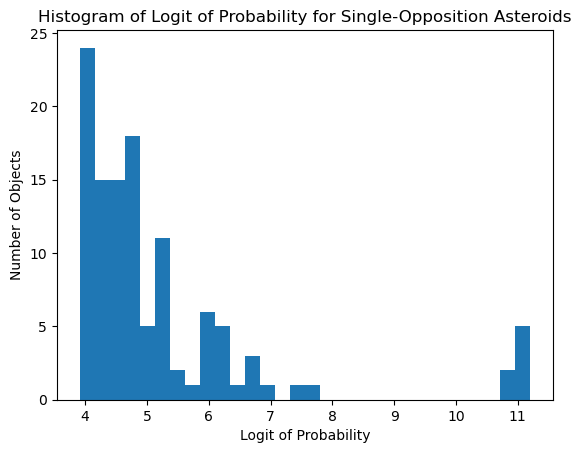

In [ ]:
# plot histogram of logit_prob

tempout = final[(final["Arc_length"]>15)
      &(final["Num_obs"]>12)
      &(final["prob"]>0.98)
      &(final["TJ"]>3.02)
      &(final["extension_difficulty"]<0.02)
      &(final["H_diff_abs_max"]<0.6)
      &(final["Orbital_period"]<20)]
tempout["logit_prob"] = np.log(tempout["prob"]/(1-tempout["prob"]))

plt.hist(tempout["logit_prob"], bins=30)
plt.xlabel("Logit of Probability")
plt.ylabel("Number of Objects")
plt.title("Histogram of Logit of Probability for Single-Opposition Asteroids")
plt.show()

/var/folders/q_/q72gghqx0dbbrygb127lyk2m0000gp/T/ipykernel_13462/1055535449.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tempout["logit_prob"] = np.log(tempout["prob"] / (1 - tempout["prob"]))


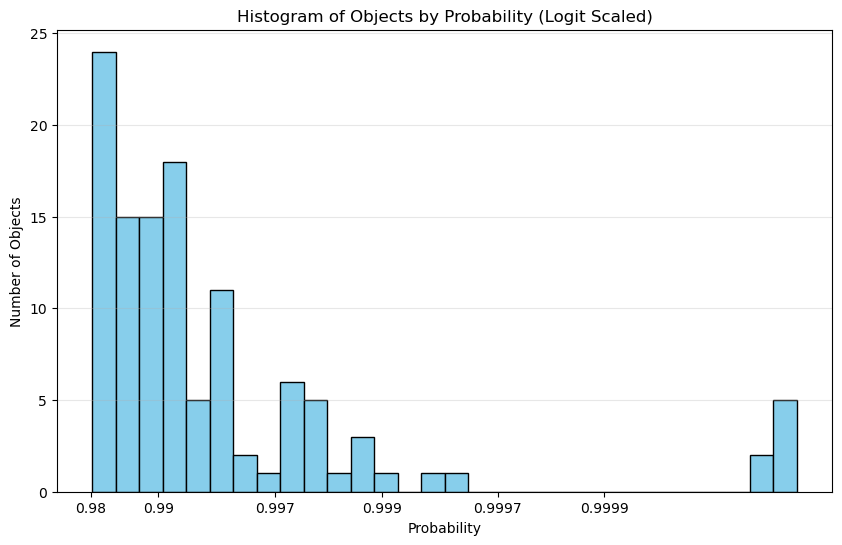

In [ ]:
# 1. Calculate logit as before
tempout["logit_prob"] = np.log(tempout["prob"] / (1 - tempout["prob"]))

# 2. Plot the histogram
plt.figure(figsize=(10, 6))
plt.hist(tempout["logit_prob"], bins=30, color='skyblue', edgecolor='black')

# 3. Define the probability values you want to see on the X-axis
# Since your filter is prob > 0.98, we choose values in that range
prob_ticks = np.array([0.98, 0.99, 0.997, 0.999, 0.9997, 0.9999])

# 4. Convert those probability labels into logit space for positioning
logit_ticks = np.log(prob_ticks / (1 - prob_ticks))

# 5. Apply the ticks and labels
plt.xticks(logit_ticks, labels=[f"{p}" for p in prob_ticks])

plt.xlabel("Probability")
plt.ylabel("Number of Objects")
plt.title("Histogram of Objects by Probability (Logit Scaled)")
plt.grid(axis='y', alpha=0.3)
plt.show()

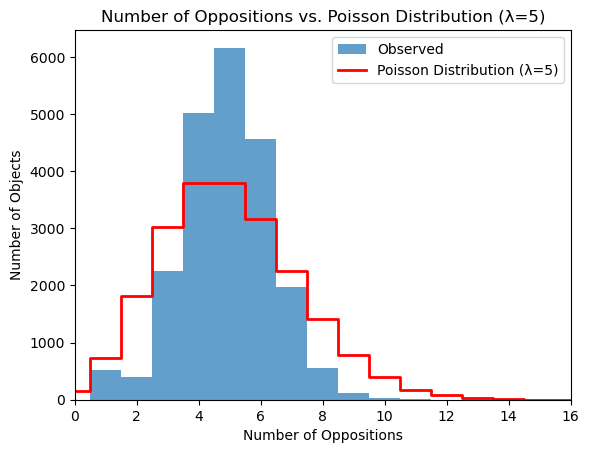

In [ ]:
# 1. Filter the data (as per your logic)
# Note: Filtering for 4.9 < x < 5.1 effectively selects objects where exp_Num_opps is 5

final_56 = final[(final["exp_Num_opps"] > 4.9) & (final["exp_Num_opps"] < 5.1)]
final_56 = final_56[final_56["Num_obs"] > 13]

# 2. Plot the histogram
# Bins [0.5, 1.5, 2.5...] center the bars on integers 1, 2, 3...
plt.hist(final_56["Num_opps"], bins=np.arange(0.5, 16.5, 1), alpha=0.7, label='Observed')

# 3. Prepare Poisson distribution data
x = np.arange(0, 17) # Range to cover the histogram bins
lambda_ = 5
poisson_pmf = poisson.pmf(x, lambda_)
# Scale PMF by the number of objects to match the histogram frequency
y = poisson_pmf * len(final_56)

# 4. Plot the red line as a stepwise function
# 'where='mid'' aligns the horizontal steps with the centers of the histogram bins
plt.step(x, y, color='red', where='mid', linewidth=2, label='Poisson Distribution (λ=5)')

# Formatting
plt.xlabel("Number of Oppositions")
plt.ylabel("Number of Objects")
plt.title("Number of Oppositions vs. Poisson Distribution (λ=5)")
plt.legend()
plt.xlim(0, 16)
plt.show()

/Users/petervw/mambaforge/envs/automl5/lib/python3.11/site-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/Users/petervw/mambaforge/envs/automl5/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


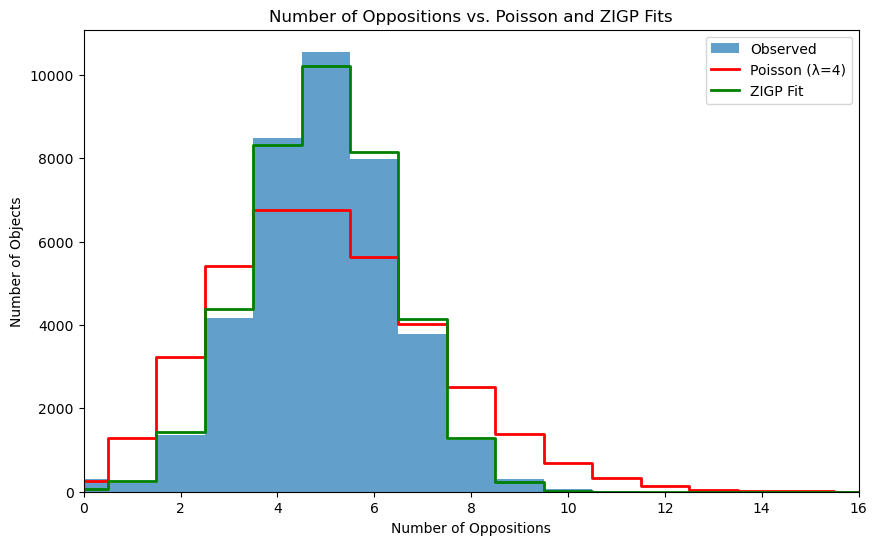

In [ ]:


# ... [Your previous data loading/filtering code] ...
# Assuming 'final' is already loaded as per your context

# 1. Filter the data
final_56 = final[(final["exp_Num_opps"] > 5.8) & (final["exp_Num_opps"] < 6.2)]
final_56 = final_56[final_56["Num_obs"] > 13]
final_56["exp_Num_Recov"] = final_56["exp_Num_opps"] - 1
final_56["Num_Recov"] = final_56["Num_opps"] - 1

# 2. Plot the histogram
plt.figure(figsize=(10, 6))
plt.hist(final_56["Num_Recov"], bins=np.arange(-0.5, 16.5, 1), alpha=0.7, label='Observed')

# 3. Prepare Poisson distribution data (Red Line)
x = np.arange(0, 17)
lambda_ = 5
poisson_pmf = poisson.pmf(x, lambda_)
y_poisson = poisson_pmf * len(final_56)
plt.step(x, y_poisson, color='red', where='mid', linewidth=2, label='Poisson (λ=4)')

# ---------------------------------------------------------
# 4. Fit ZIGP and Plot (Green Line)
# ---------------------------------------------------------

# Prepare data for Statsmodels
# We need an 'intercept' (column of 1s) to fit the mean of the distribution
endog = final_56["Num_Recov"]
exog = np.ones((len(endog), 1))

# Initialize and fit the ZIGP model
# inflation='logit' is the standard method for modeling the zero-inflation probability
zigp_model = sm.ZeroInflatedGeneralizedPoisson(endog, exog, inflation='logit')
res_zigp = zigp_model.fit(disp=0)  # disp=0 suppresses convergence messages

# Calculate predicted PMF
# We use a single dummy observation [1] to predict the distribution curve
exog_pred = np.array([[1.0]])
zigp_dist = res_zigp.get_distribution(exog=exog_pred)
zigp_pmf = zigp_dist.pmf(x) # Get PMF for x = 0..16

# Depending on statsmodels version, the output shape might vary. 
# We ensure it's a flat array matching 'x'
if zigp_pmf.ndim > 1:
    zigp_pmf = zigp_pmf.flatten()

# Scale to match histogram counts
y_zigp = zigp_pmf * len(final_56)

# Plot the green line
plt.step(x, y_zigp, color='green', where='mid', linewidth=2, label='ZIGP Fit')
# ---------------------------------------------------------

# Formatting
plt.xlabel("Number of Oppositions")
plt.ylabel("Number of Objects")
plt.title("Number of Oppositions vs. Poisson and ZIGP Fits")
plt.legend()
plt.xlim(0, 16)
plt.show()

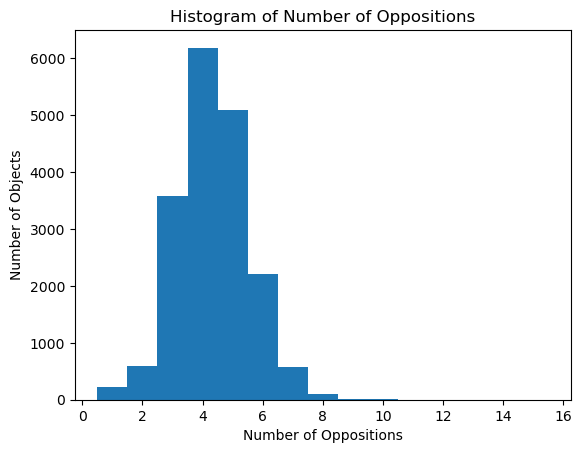

In [ ]:
# filter final for objects with exp_Num_opps between 5 and 6
final_56 = final[(final["exp_Num_opps"]>4) & (final["exp_Num_opps"]<4.2)]
final_56 = final_56[final_56["Num_obs"]>30]
# show a histogram of number of opps for final_56
plt.hist(final_56["Num_opps"], bins=np.arange(0.5, 16.5, 1))
plt.xlabel("Number of Oppositions")
plt.ylabel("Number of Objects")
plt.title("Histogram of Number of Oppositions")
plt.show()

In [ ]:
# A curiousity: some of the most over-observed objects!
final_low = final[(final["exp_Num_opps"]>1) & (final["exp_Num_opps"]<1.5)]
final_low = final_low[final_low["Num_obs"]>13]
final_low = final_low[final_low["q"]>=1.3]

final_low.sort_values(by="Num_opps_mult", ascending=True)[['Number','H','Num_opps','Num_opps_mult','exp_Num_opps','prob']]

,Number,H,Num_opps,Num_opps_mult,exp_Num_opps,prob
Principal_desig,,,,,,
2010 BA118,<NA>,24.82,8,0.131779,1.054233,0.000924
2010 DQ72,<NA>,25.12,5,0.208624,1.043121,0.000908
2013 AJ174,<NA>,19.91,5,0.247404,1.237021,0.003857
2013 AT165,<NA>,21.31,5,0.254264,1.271322,0.009254
2013 HA90,<NA>,20.89,5,0.254914,1.274571,0.006986
...,...,...,...,...,...,...
2025 KN4,<NA>,18.55,1,1.499873,1.499873,0.008842
2023 SE21,<NA>,20.02,1,1.499894,1.499894,0.006015
2017 QV100,<NA>,20.35,1,1.499937,1.499937,0.009441


## On to some tables

In [ ]:
# Brightest objects with 2023 or later initial linkage and designation, used to identify 2024 SG49 which is references in the paper (2024 KK2 could equally have been used)
cols_to_show = ["Num_obs","Num_opps","Ref","Arc_length","prob", "exp_Num_opps", "Num_opps_diff", "Num_opps_mult", "extension_difficulty"]
tempout = final[(final.index.str[0:4].astype(int)>=2023)
                &(final.index.str[0:4].astype(int)<=2026)
                &(final["extension_difficulty"]<0.3)
      &(final["prob"]>0.999)]
tempout = tempout[cols_to_show]
tempout.head(20).to_clipboard()
tempout.head(20)

,Num_obs,Num_opps,Ref,Arc_length,prob,exp_Num_opps,Num_opps_diff,Num_opps_mult,extension_difficulty
Principal_desig,,,,,,,,,
2025 VZ8,48,1,E2026-BC2,29,0.999986,12.958137,11.958137,12.958137,0.000010
2023 T-2,501,16,E2025-WI2,<NA>,0.999986,13.758163,-2.241837,0.859885,0.000076
2025 HV38,48,1,E2026-C09,51,0.999984,15.633950,14.63395,15.63395,0.000002
2023 RO65,54,9,E2026-BC2,<NA>,0.999983,10.333037,1.333037,1.148115,0.000197
2023 UW14,87,8,MPO924210,<NA>,0.999973,10.038040,2.03804,1.254755,0.000076
2023 FW6,47,8,E2026-BI4,<NA>,0.999968,9.726887,1.726887,1.215861,0.000091
2025 MU104,44,7,E2026-C73,<NA>,0.999967,11.296895,4.296895,1.613842,0.000080
2023 NC4,96,11,MPO892948,<NA>,0.999966,11.253040,0.25304,1.023004,0.000076
2024 SG49,65,10,E2026-A87,<NA>,0.999965,13.118217,3.118217,1.311822,0.000076


In [ ]:
# Discoveries, rediscoveries, under investigation and slightly sub threshold examples
objects_to_include_in_data_table = ['2001 BV70',
 '2019 OE31',
 '2008 BJ22',
 '2007 VB146',
 '2025 HV38',
 '2015 BC566',
 '2025 VZ8',
 '2021 AY8',
 '2009 FP8',
 '2018 BJ11',
 '2002 CW116',
 '2024 XE22',
 '2009 DP2',
'2020 QQ62',
'2019 GT10',
 '2010 RH69','2008 GO98','2017 QN84','2003 BM80',
 '2017 VB','2012 XK149','2020 PB54',
 '2021 EA45','2017 PZ20','2020 BO57','2022 PH33', '2010 WE48',
 '2006 PD30',
 '2017 FV167','2024 TS82','2014 WL185','2008 VK110']

# False Positives to discuss
objects_fp = ['2025 HB52', # brightest extension in last year
              '2023 UQ87', # photometry issues
              '2025 WW35', '2019 GX101', # one night recoveries
               '2015 FH479', '2014 DZ209','2009 US21','2009 AN42','2009 VW92', #mislinkages
               '2002 GR31','2024 SG49',
              ]

In [ ]:
for_paper = final.copy()
for_paper["Principal_desig"] = for_paper.index
for_paper["Object"] = for_paper["Number"].astype(str) + " " + for_paper["Principal_desig"]
# replace "<NA> " with ""
for_paper["Object"] = for_paper["Object"].str.replace("<NA> ", "")

In [ ]:
statuses = pd.read_excel("Object statuses.xlsx")

In [ ]:
#
# COMET TABLE AND ASTEROID TABLE
#

# 1. Prepare the raw data
# Combine main table and comet table
table_for_paper = pd.concat([
    for_paper[for_paper["Principal_desig"].isin(objects_to_include_in_data_table)][["Object","a","e","i","H","TJ","Num_opps","prob","exp_Num_opps"]],
    cometmerge[cometmerge["Designation_and_name"].isin(discoveries_in_comet_file)][["Designation_and_name","a","e","i","H","TJ","Num_opps","prob","exp_Num_opps"]].rename(columns={"Designation_and_name": "Object"})
], ignore_index=True)

# Merge metadata and sort
table_for_paper = table_for_paper.merge(statuses[["Object","Status"]], on="Object", how="left")
table_for_paper.sort_values(by=["prob"], ascending=False, inplace=True)

# 2. Define column renaming
renames = {
    "TJ": "T_J",
    "prob": "P(N_{\\text{opp}} \ge 4)",
    "Num_opps": "N_{\\text{opp}}",
    "exp_Num_opps": "E[N_{\\text{opp}}]",
    "H": "H_V"
}
table_for_paper = table_for_paper.rename(columns=renames)

# 3. Build the Formatter Dictionary
format_dict = {}
prob_col = "P(N_{\\text{opp}} \ge 4)"
int_cols = ["N_{\\text{opp}}"]

for col in table_for_paper.columns:
    if col == prob_col:
        # User requested exactly 6 decimals for the probability
        format_dict[col] = "{:.6f}"

    elif col in int_cols:
        format_dict[col] = "{:.0f}"
    
    elif table_for_paper[col].dtype.kind in 'ifc':  # If column is numeric
        # Logic: Calculate decimals needed so the median value has 3 sig figs
        median_val = table_for_paper[col].abs().median()
        
        if pd.isna(median_val) or median_val == 0:
            format_dict[col] = "{:.3f}"
        else:
            # Order of magnitude: floor(log10(val))
            # Decimals = (SigFigs - 1) - magnitude
            magnitude = np.floor(np.log10(median_val))
            decimals = int(max(0, (3 - 1) - magnitude))
            format_dict[col] = "{:." + str(decimals) + "f}"

# 4. Generate LaTeX Outputs via Styler
# We split the dataframe based on T_J, then apply styling
tj_mask = table_for_paper["T_J"].astype(float) < 3

# Helper to stylize and print correctly
def print_styled_latex(df_subset, label):
    # 1. Initialize the styler
    # 2. Apply formatting and replace NaNs
    # 3. Hide the index (this replaces index=False)
    styler = (
        df_subset.style
        .format(format_dict, na_rep="")
        .hide(axis='index')
    )
    
    print(f"% --- Table for {label} ---")
    # In recent Pandas versions, use hrules=True for booktabs (standard for papers)
    print(styler.to_latex(hrules=True))
    print("\n")

# Generate the outputs
tj_mask = table_for_paper["T_J"].astype(float) < 3.02
print_styled_latex(table_for_paper[tj_mask], "T_J < 3.02")
print_styled_latex(table_for_paper[~tj_mask], "T_J >= 3.02")
# print_styled_latex(table_for_paper, "ALL")


% --- Table for T_J < 3.02 ---
\begin{tabular}{lrrrrrrrrl}
\toprule
Object & a & e & i & H_V & T_J & N_{\text{opp}} & P(N_{\text{opp}} \ge 4) & E[N_{\text{opp}}] & Status \\
\midrule
P/2025 UX109 (Ye) & 3.80 & 0.324 & 3.18 & 15.0 & 2.98 &  & 0.999986 & 15.5 & Comet \\
2010 RH69 & 4.53 & 0.057 & 11.55 & 13.9 & 2.97 & 3 & 0.999986 & 15.7 & Sam? \\
(323137) 2003 BM80 & 4.23 & 0.188 & 5.81 & 13.6 & 2.99 & 7 & 0.999985 & 15.8 & Comet \\
(457175) 2008 GO98 & 3.97 & 0.279 & 15.56 & 12.9 & 2.93 & 7 & 0.999984 & 15.8 & Comet \\
2019 OE31 & 4.38 & 0.100 & 5.22 & 14.7 & 3.01 & 1 & 0.999983 & 15.6 & "Vacationing Centaur" \\
P/2022 BV9 (Lemmon) & 4.36 & 0.235 & 11.93 & 13.8 & 2.93 &  & 0.999982 & 15.9 & Comet \\
2017 QN84 & 3.77 & 0.344 & 12.07 & 15.1 & 2.94 & 4 & 0.999974 & 11.4 & Comet \\
2001 BV70 & 3.59 & 0.426 & 4.33 & 15.1 & 2.95 & 1 & 0.999973 & 15.2 & Suspected Comet, Neg. (Pre)covery \\
2018 BJ11 & 4.18 & 0.225 & 3.42 & 15.6 & 2.99 & 1 & 0.999844 & 9.9 & Comet \\
2008 VK110 & 7.17 & 0.381 

/var/folders/q_/q72gghqx0dbbrygb127lyk2m0000gp/T/ipykernel_13462/3799800816.py:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  table_for_paper = pd.concat([


In [ ]:
#
# FALSE POSITIVES TABLE
#

# 1. Prepare the raw data
# Combine main table and comet table
table_for_paper = pd.concat([
    for_paper[for_paper["Principal_desig"].isin(objects_fp)][["Object","a","e","i","H","TJ","Num_opps","prob","exp_Num_opps"]],
    # cometmerge[cometmerge["Designation_and_name"].isin(discoveries_in_comet_file)][["Designation_and_name","a","e","i","H","TJ","Num_opps","prob","exp_Num_opps"]].rename(columns={"Designation_and_name": "Object"})
], ignore_index=True)

# Merge metadata and sort
table_for_paper = table_for_paper.merge(statuses[["Object","Status"]], on="Object", how="left")
table_for_paper.sort_values(by=["prob"], ascending=False, inplace=True)

# 2. Define column renaming
renames = {
    "TJ": "T_J",
    "prob": "P(N_{\\text{opp}} \ge 4)",
    "Num_opps": "N_{\\text{opp}}",
    "exp_Num_opps": "E[N_{\\text{opp}}]",
    "H": "H_V"
}
table_for_paper = table_for_paper.rename(columns=renames)

# 3. Build the Formatter Dictionary
format_dict = {}
prob_col = "P(N_{\\text{opp}} \ge 4)"
int_cols = ["N_{\\text{opp}}"]

for col in table_for_paper.columns:
    if col == prob_col:
        # User requested exactly 6 decimals for the probability
        format_dict[col] = "{:.6f}"

    elif col in int_cols:
        format_dict[col] = "{:.0f}"
    
    elif table_for_paper[col].dtype.kind in 'ifc':  # If column is numeric
        # Logic: Calculate decimals needed so the median value has 3 sig figs
        median_val = table_for_paper[col].abs().median()
        
        if pd.isna(median_val) or median_val == 0:
            format_dict[col] = "{:.3f}"
        else:
            # Order of magnitude: floor(log10(val))
            # Decimals = (SigFigs - 1) - magnitude
            magnitude = np.floor(np.log10(median_val))
            decimals = int(max(0, (3 - 1) - magnitude))
            format_dict[col] = "{:." + str(decimals) + "f}"

# 4. Generate LaTeX Outputs via Styler
# We split the dataframe based on T_J, then apply styling
tj_mask = table_for_paper["T_J"].astype(float) < 3

# Helper to stylize and print correctly
def print_styled_latex(df_subset, label):
    # 1. Initialize the styler
    # 2. Apply formatting and replace NaNs
    # 3. Hide the index (this replaces index=False)
    styler = (
        df_subset.style
        .format(format_dict, na_rep="")
        .hide(axis='index')
    )
    
    print(f"% --- Table for {label} ---")
    # In recent Pandas versions, use hrules=True for booktabs (standard for papers)
    print(styler.to_latex(hrules=True))
    print("\n")

# Generate the outputs
tj_mask = table_for_paper["T_J"].astype(float) < 3
# print_styled_latex(table_for_paper[tj_mask], "T_J < 3")
# print_styled_latex(table_for_paper[~tj_mask], "T_J >= 3")
print_styled_latex(table_for_paper, "ALL")


% --- Table for ALL ---
\begin{tabular}{lrrrrrrrrl}
\toprule
Object & a & e & i & H_V & T_J & N_{\text{opp}} & P(N_{\text{opp}} \ge 4) & E[N_{\text{opp}}] & Status \\
\midrule
2009 AN42 & 2.60 & 0.165 & 1.35 & 16.7 & 3.39 & 1 & 0.999985 & 15.5 & Likely Mislinkage \\
2014 DZ209 & 2.44 & 0.162 & 1.27 & 17.2 & 3.48 & 1 & 0.999984 & 15.5 & Likely Mislinkage \\
2015 FH479 & 2.88 & 0.066 & 7.84 & 17.2 & 3.28 & 1 & 0.999970 & 11.2 & Likely Mislinkage \\
(826830) 2024 SG49 & 2.54 & 0.197 & 3.96 & 17.4 & 3.41 & 10 & 0.999965 & 13.1 &  \\
2025 HB52 & 2.80 & 0.072 & 4.90 & 17.6 & 3.31 & 3 & 0.999939 & 10.6 & Linked with two prior opps in ITF \\
2002 GR31 & 2.81 & 0.204 & 14.60 & 16.7 & 3.24 & 1 & 0.999319 & 8.0 &  \\
2023 UQ87 & 2.75 & 0.079 & 0.78 & 17.4 & 3.34 & 1 & 0.948806 & 6.0 & Bad Photometry \\
2019 GX101 & 2.75 & 0.031 & 3.91 & 18.2 & 3.34 & 1 & 0.918524 & 5.5 & Found 1 night in ITF, need to find 2nd \\
\bottomrule
\end{tabular}





In [ ]:
raise Exception("Stop here for now.")

Exception: Stop here for now.

# Nearest Neighbor Code
You can use this to troubleshoot or figure out why an object is getting the ratings it is getting.

In [ ]:
obj_to_examine = "2014 OV26"

nn_cols = ["vis_0", "H", "e", "i", "node_plus_peri", "Peri", "Node"]#"Peri"] #"Tp", 
scaler = StandardScaler()
final_normalized = scaler.fit_transform(final[nn_cols])
nn = NearestNeighbors(n_neighbors=25)
nn.fit(final_normalized)
obj = final[final.index==obj_to_examine][nn_cols]
obj_normalized = scaler.transform(obj)
distances, indices = nn.kneighbors(obj_normalized)
final.iloc[indices[0]][["H","a","e","i", "Tp", "Node", "Peri", "Tp", "Num_opps", "extension_difficulty", "exp_Num_opps", "prob"]]

,H,a,e,i,Tp,Node,Peri,Tp,Num_opps,extension_difficulty,exp_Num_opps,prob
Principal_desig,,,,,,,,,,,,
2014 OV26,18.16,2.788729,0.065088,1.8216,2457674.84759,125.35861,353.73957,2457674.84759,1,0.007286,6.325931,0.964944
2015 DQ85,18.02,2.928634,0.068355,2.98811,2460601.97349,130.25283,355.27036,2460601.97349,5,0.000074,5.568408,0.900729
2015 DJ348,18.06,2.893613,0.076088,2.38577,2460440.2256,137.63775,343.90494,2460440.2256,5,0.000075,5.628932,0.917027
2016 CB316,18.21,2.647283,0.055495,2.68993,2460431.63641,123.5123,351.3933,2460431.63641,8,0.000076,8.244326,0.997387
2016 JE87,18.39,2.663144,0.057693,2.47994,2460250.54043,109.92687,357.58394,2460250.54043,6,0.000032,6.209036,0.961758
2023 XH40,18.25,2.914091,0.065105,2.58271,2460479.14458,120.48924,354.07457,2460479.14458,1,0.404199,4.511762,0.694470
2020 BJ175,18.2,2.920884,0.054306,3.11643,2460619.79367,121.55767,352.24777,2460619.79367,5,0.000080,4.726528,0.769444
2014 HD331,18.52,2.65042,0.078523,1.67486,2461082.67428,111.86983,357.67473,2461082.67428,3,0.986343,5.891230,0.943658
2018 GU39,17.8,2.950302,0.070719,0.40426,2461493.57441,124.46456,348.62255,2461493.57441,6,0.000052,7.394772,0.977097


# Variant Orbit Examination

In [ ]:
var_orbs = """00001   17.90  0.15 K262I 152.24281   27.64839  322.97462    1.63045  0.0823479  0.23441982   2.6049926    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [1]                 20260218
00002   17.83  0.15 K262I 160.20460   20.25129  323.07161    1.69034  0.0960834  0.23536447   2.5980178    FO 260222    14   1    9 days 0.09 M-P 06  Find_Orb   0000 K26C04V [2]                 20260218
00003   17.83  0.15 K262I 158.32285   21.80090  323.07219    1.69055  0.0967820  0.23528060   2.5986351    FO 260222    14   1    9 days 0.12 M-P 06  Find_Orb   0000 K26C04V [3]                 20260218
00004   17.59  0.15 K262I 174.49683    7.54475  323.38309    1.90854  0.1518294  0.23885153   2.5726697    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [4]                 20260218
00005   17.00  0.15 K262I 189.47235  357.52604  324.13476    2.68577  0.3310300  0.24986307   2.4965178    FO 260222    14   1    9 days 0.13 M-P 06  Find_Orb   0000 K26C04V [5]                 20260218
00006   18.20  0.15 K262I  98.34873   80.49982  322.55601    1.40728  0.0494537  0.23177571   2.6247670    FO 260222    14   1    9 days 0.13 M-P 06  Find_Orb   0000 K26C04V [6]                 20260218
00007   18.03  0.15 K262I 134.76390   44.61176  322.79552    1.52888  0.0615590  0.23307270   2.6150206    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [7]                 20260218
00008   17.63  0.15 K262I 174.93831    7.32511  323.34164    1.87653  0.1432720  0.23838381   2.5760337    FO 260222    14   1    9 days 0.13 M-P 06  Find_Orb   0000 K26C04V [8]                 20260218
00009   17.54  0.15 K262I 177.38891    5.25888  323.45241    1.96341  0.1657088  0.23973982   2.5663109    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [9]                 20260218
00010   17.23  0.15 K262I 184.88501  359.91143  323.84951    2.33632  0.2559067  0.24534987   2.5270403    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [10]                20260218
00011   17.69  0.15 K262I 168.65602   12.43568  323.25764    1.81519  0.1282929  0.23731491   2.5837631    FO 260222    14   1    9 days 0.12 M-P 06  Find_Orb   0000 K26C04V [11]                20260218
00012   17.64  0.15 K262I 170.75264   10.58060  323.31710    1.85855  0.1392735  0.23799215   2.5788592    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [12]                20260218
00013   17.46  0.15 K262I 177.69573    4.83165  323.56644    2.05974  0.1895489  0.24117820   2.5560971    FO 260222    14   1    9 days 0.13 M-P 06  Find_Orb   0000 K26C04V [13]                20260218
00014   17.64  0.15 K262I 170.97008   10.37586  323.32892    1.86728  0.1411996  0.23810404   2.5780512    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [14]                20260218
00015   17.37  0.15 K262I 181.92706    1.83058  323.67342    2.15745  0.2133049  0.24269613   2.5454280    FO 260222    14   1    9 days 0.12 M-P 06  Find_Orb   0000 K26C04V [15]                20260218
00016   17.58  0.15 K262I 175.29122    6.90915  323.40206    1.92346  0.1551241  0.23906166   2.5711619    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [16]                20260218
00017   17.43  0.15 K262I 180.47645    2.87352  323.59453    2.08449  0.1957380  0.24159396   2.5531638    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [17]                20260218
00018   17.30  0.15 K262I 183.61075    0.70410  323.76881    2.25111  0.2364933  0.24415886   2.5352515    FO 260222    14   1    9 days 0.12 M-P 06  Find_Orb   0000 K26C04V [18]                20260218
00019   17.98  0.15 K262I 144.47052   35.44622  322.86006    1.56389  0.0662710  0.23361318   2.6109857    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [19]                20260218
00020   17.69  0.15 K262I 171.14157   10.50217  323.25942    1.81645  0.1275482  0.23738192   2.5832769    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [20]                20260218
00021   18.42  0.15 K262I  58.61837  119.13291  322.24534    1.27096  0.0685787  0.23077435   2.6323544    FO 260222    14   1    9 days 0.15 M-P 06  Find_Orb   0000 K26C04V [21]                20260218
00022   17.90  0.15 K262I 154.63727   25.64290  322.97205    1.62874  0.0809547  0.23451997   2.6042509    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [22]                20260218
00023   18.07  0.15 K262I 127.62819   51.68413  322.73785    1.49790  0.0560880  0.23271670   2.6176868    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [23]                20260218
00024   17.50  0.15 K262I 177.25830    5.24655  323.50894    2.01014  0.1771184  0.24040262   2.5615918    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [24]                20260218
00025   17.83  0.15 K262I 158.13692   21.96326  323.06870    1.68853  0.0966867  0.23527649   2.5986654    FO 260222    14   1    9 days 0.12 M-P 06  Find_Orb   0000 K26C04V [25]                20260218
00026   18.23  0.15 K262I  90.22950   88.67651  322.50767    1.38467  0.0484954  0.23164083   2.6257858    FO 260222    14   1    9 days 0.12 M-P 06  Find_Orb   0000 K26C04V [26]                20260218
00027   18.10  0.15 K262I 122.86168   56.46823  322.69992    1.47853  0.0528094  0.23253554   2.6190462    FO 260222    14   1    9 days 0.12 M-P 06  Find_Orb   0000 K26C04V [27]                20260218
00028   17.90  0.15 K262I 153.29502   26.80185  322.96913    1.62736  0.0810596  0.23445425   2.6047376    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [28]                20260218
00029   18.01  0.15 K262I 139.89147   39.86926  322.81958    1.54161  0.0622460  0.23332778   2.6131144    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [29]                20260218
00030   17.55  0.15 K262I 175.73701    6.49505  323.43606    1.95031  0.1626016  0.23950401   2.5679951    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [30]                20260218
00031   17.97  0.15 K262I 143.53109   36.05389  322.87821    1.57434  0.0698641  0.23363202   2.6108453    FO 260222    14   1    9 days 0.12 M-P 06  Find_Orb   0000 K26C04V [31]                20260218
00032   17.73  0.15 K262I 167.73756   13.42313  323.19996    1.77505  0.1172632  0.23670640   2.5881893    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [32]                20260218
00033   17.58  0.15 K262I 174.36875    7.60207  323.39849    1.92033  0.1544570  0.23899112   2.5716678    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [33]                20260218
00034   18.13  0.15 K262I 113.07389   65.72607  322.65623    1.45588  0.0534425  0.23216266   2.6218497    FO 260222    14   1    9 days 0.14 M-P 06  Find_Orb   0000 K26C04V [34]                20260218
00035   18.29  0.15 K262I  78.63841  100.19070  322.43016    1.34970  0.0503050  0.23143086   2.6273738    FO 260222    14   1    9 days 0.13 M-P 06  Find_Orb   0000 K26C04V [35]                20260218
00036   17.81  0.15 K262I 161.14314   19.33251  323.09356    1.70422  0.0997693  0.23556823   2.5965194    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [36]                20260218
00037   18.15  0.15 K262I 111.68167   67.61835  322.62728    1.44192  0.0482069  0.23218722   2.6216648    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [37]                20260218
00038   17.73  0.15 K262I 169.76090   11.81115  323.20071    1.77517  0.1170121  0.23679414   2.5875500    FO 260222    14   1    9 days 0.12 M-P 06  Find_Orb   0000 K26C04V [38]                20260218
00039   17.52  0.15 K262I 176.63052    5.75203  323.47977    1.98581  0.1713605  0.24005356   2.5640743    FO 260222    14   1    9 days 0.09 M-P 06  Find_Orb   0000 K26C04V [39]                20260218
00040   17.93  0.15 K262I 151.83480   28.35642  322.93411    1.60621  0.0755780  0.23419810   2.6066365    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [40]                20260218
00041   17.94  0.15 K262I 148.67062   31.22994  322.91629    1.59602  0.0739880  0.23399549   2.6081409    FO 260222    14   1    9 days 0.09 M-P 06  Find_Orb   0000 K26C04V [41]                20260218
00042   17.92  0.15 K262I 152.12272   28.02475  322.94182    1.61114  0.0771341  0.23426332   2.6061527    FO 260222    14   1    9 days 0.12 M-P 06  Find_Orb   0000 K26C04V [42]                20260218
00043   17.60  0.15 K262I 173.62238    8.20246  323.38217    1.90778  0.1513624  0.23878918   2.5731175    FO 260222    14   1    9 days 0.09 M-P 06  Find_Orb   0000 K26C04V [43]                20260218
00044   17.54  0.15 K262I 175.64763    6.50300  323.46118    1.97057  0.1674085  0.23977672   2.5660476    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [44]                20260218
00045   17.84  0.15 K262I 158.59003   21.67040  323.05883    1.68169  0.0944826  0.23521540   2.5991153    FO 260222    14   1    9 days 0.13 M-P 06  Find_Orb   0000 K26C04V [45]                20260218
00046   17.61  0.15 K262I 173.21203    8.56699  323.36260    1.89274  0.1476462  0.23856800   2.5747077    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [46]                20260218
00047   17.37  0.15 K262I 180.79082    2.58771  323.67030    2.15475  0.2131202  0.24267445   2.5455796    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [47]                20260218
00048   17.85  0.15 K262I 159.55121   20.99661  323.04192    1.67144  0.0910009  0.23513063   2.5997399    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [48]                20260218
00049   18.10  0.15 K262I 124.37205   55.19942  322.69987    1.47811  0.0511035  0.23260921   2.6184932    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [49]                20260218
00050   17.72  0.15 K262I 169.50865   11.93818  323.21888    1.78825  0.1203812  0.23694634   2.5864418    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [50]                20260218
00051   17.43  0.15 K262I 178.80111    4.02335  323.59372    2.08388  0.1957434  0.24158214   2.5532470    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [51]                20260218
00052   17.65  0.15 K262I 172.74507    9.07527  323.31435    1.85646  0.1379218  0.23800893   2.5787380    FO 260222    14   1    9 days 0.09 M-P 06  Find_Orb   0000 K26C04V [52]                20260218
00053   17.84  0.15 K262I 162.12763   18.77037  323.05402    1.67937  0.0923907  0.23530694   2.5984412    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [53]                20260218
00054   17.79  0.15 K262I 163.09169   17.55393  323.12348    1.72366  0.1046646  0.23587397   2.5942751    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [54]                20260218
00055   17.88  0.15 K262I 159.31847   21.43566  323.00565    1.64935  0.0849453  0.23488711   2.6015365    FO 260222    14   1    9 days 0.12 M-P 06  Find_Orb   0000 K26C04V [55]                20260218
00056   17.66  0.15 K262I 172.43829    9.36452  323.29684    1.84363  0.1348104  0.23782135   2.5800937    FO 260222    14   1    9 days 0.09 M-P 06  Find_Orb   0000 K26C04V [56]                20260218
00057   17.19  0.15 K262I 185.60779  359.49318  323.89977    2.39165  0.2690798  0.24616319   2.5214710    FO 260222    14   1    9 days 0.15 M-P 06  Find_Orb   0000 K26C04V [57]                20260218
00058   18.00  0.15 K262I 142.85274   37.09591  322.83774    1.55144  0.0634243  0.23348133   2.6119685    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [58]                20260218
00059   17.89  0.15 K262I 156.20572   24.17638  322.98945    1.63915  0.0833612  0.23466866   2.6031508    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [59]                20260218
00060   17.78  0.15 K262I 165.42842   15.59073  323.13804    1.73328  0.1060494  0.23606970   2.5928410    FO 260222    14   1    9 days 0.13 M-P 06  Find_Orb   0000 K26C04V [60]                20260218
00061   17.65  0.15 K262I 170.87996   10.48934  323.31691    1.85829  0.1388468  0.23797096   2.5790122    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [61]                20260218
00062   17.93  0.15 K262I 151.44946   28.67069  322.93623    1.60771  0.0760182  0.23420436   2.6065901    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [62]                20260218
00063   17.82  0.15 K262I 160.57485   19.90174  323.07762    1.69424  0.0971648  0.23542468   2.5975748    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [63]                20260218
00064   17.69  0.15 K262I 169.85624   11.53057  323.25160    1.81084  0.1265887  0.23727992   2.5840171    FO 260222    14   1    9 days 0.09 M-P 06  Find_Orb   0000 K26C04V [64]                20260218
00065   17.97  0.15 K262I 145.24961   34.52159  322.88077    1.57592  0.0698343  0.23371671   2.6102145    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [65]                20260218
00066   18.02  0.15 K262I 138.40637   41.22127  322.81576    1.53934  0.0622543  0.23325092   2.6136884    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [66]                20260218
00067   17.74  0.15 K262I 166.56505   14.40737  323.18715    1.76612  0.1156393  0.23657561   2.5891432    FO 260222    14   1    9 days 0.12 M-P 06  Find_Orb   0000 K26C04V [67]                20260218
00068   18.03  0.15 K262I 134.84860   44.62910  322.79155    1.52620  0.0603271  0.23307295   2.6150187    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [68]                20260218
00069   17.65  0.15 K262I 171.60841    9.93165  323.31671    1.85840  0.1388761  0.23801842   2.5786694    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [69]                20260218
00070   17.90  0.15 K262I 152.57733   27.34976  322.97417    1.63041  0.0825719  0.23445602   2.6047244    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [70]                20260218
00071   17.92  0.15 K262I 152.63735   27.52119  322.95197    1.61683  0.0781173  0.23432540   2.6056923    FO 260222    14   1    9 days 0.09 M-P 06  Find_Orb   0000 K26C04V [71]                20260218
00072   17.99  0.15 K262I 141.52215   38.10700  322.85027    1.55853  0.0662199  0.23346304   2.6121050    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [72]                20260218
00073   17.74  0.15 K262I 166.61675   14.32353  323.19678    1.77292  0.1171897  0.23665646   2.5885535    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [73]                20260218
00074   17.75  0.15 K262I 167.51731   13.72856  323.17339    1.75680  0.1120746  0.23644093   2.5901263    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [74]                20260218
00075   17.78  0.15 K262I 162.90694   17.63822  323.13605    1.73203  0.1066703  0.23596497   2.5936082    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [75]                20260218
00076   17.84  0.15 K262I 162.67181   18.30935  323.05601    1.68023  0.0924533  0.23534281   2.5981772    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [76]                20260218
00077   17.89  0.15 K262I 153.51807   26.44370  322.98857    1.63875  0.0844073  0.23456310   2.6039317    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [77]                20260218
00078   17.78  0.15 K262I 164.13906   16.66117  323.13001    1.72822  0.1057232  0.23599356   2.5933987    FO 260222    14   1    9 days 0.12 M-P 06  Find_Orb   0000 K26C04V [78]                20260218
00079   18.10  0.15 K262I 120.06491   59.03347  322.69323    1.47460  0.0536524  0.23242834   2.6198514    FO 260222    14   1    9 days 0.12 M-P 06  Find_Orb   0000 K26C04V [79]                20260218
00080   17.93  0.15 K262I 149.59220   30.23110  322.93667    1.60820  0.0773171  0.23413041   2.6071389    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [80]                20260218
00081   17.76  0.15 K262I 166.07936   14.92245  323.16420    1.75057  0.1109926  0.23632420   2.5909792    FO 260222    14   1    9 days 0.09 M-P 06  Find_Orb   0000 K26C04V [81]                20260218
00082   17.90  0.15 K262I 154.39733   25.81719  322.97672    1.63171  0.0816262  0.23451880   2.6042596    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [82]                20260218
00083   17.98  0.15 K262I 145.91708   34.15588  322.86195    1.56521  0.0661434  0.23367592   2.6105183    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [83]                20260218
00084   17.53  0.15 K262I 177.04328    5.48254  323.46658    1.97509  0.1684478  0.23987877   2.5653198    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [84]                20260218
00085   17.91  0.15 K262I 151.84993   28.06986  322.96453    1.62463  0.0807946  0.23436187   2.6054220    FO 260222    14   1    9 days 0.12 M-P 06  Find_Orb   0000 K26C04V [85]                20260218
00086   17.50  0.15 K262I 178.64896    4.25859  323.50855    2.00974  0.1772906  0.24045467   2.5612221    FO 260222    14   1    9 days 0.09 M-P 06  Find_Orb   0000 K26C04V [86]                20260218
00087   17.28  0.15 K262I 183.43979    0.80884  323.78550    2.26858  0.2402142  0.24439006   2.5336524    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [87]                20260218
00088   17.90  0.15 K262I 154.67988   25.60787  322.97435    1.63032  0.0808569  0.23450570   2.6043566    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [88]                20260218
00089   17.43  0.15 K262I 179.17529    3.76381  323.59670    2.08620  0.1957061  0.24158447   2.5532306    FO 260222    14   1    9 days 0.15 M-P 06  Find_Orb   0000 K26C04V [89]                20260218
00090   17.18  0.15 K262I 187.62707  358.30563  323.91947    2.41440  0.2743552  0.24642827   2.5196625    FO 260222    14   1    9 days 0.14 M-P 06  Find_Orb   0000 K26C04V [90]                20260218
00091   17.87  0.15 K262I 154.14602   25.71812  323.01451    1.65440  0.0881926  0.23472738   2.6027166    FO 260222    14   1    9 days 0.12 M-P 06  Find_Orb   0000 K26C04V [91]                20260218
00092   17.70  0.15 K262I 169.78058   11.59571  323.25059    1.81052  0.1262871  0.23726518   2.5841242    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [92]                20260218
00093   17.77  0.15 K262I 166.39418   14.73995  323.14923    1.74100  0.1083621  0.23620997   2.5918144    FO 260222    14   1    9 days 0.12 M-P 06  Find_Orb   0000 K26C04V [93]                20260218
00094   17.92  0.15 K262I 151.99980   28.08050  322.95038    1.61588  0.0780598  0.23428990   2.6059555    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [94]                20260218
00095   17.47  0.15 K262I 178.94297    4.00309  323.54068    2.03715  0.1841863  0.24087478   2.5582432    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [95]                20260218
00096   17.68  0.15 K262I 169.94880   11.35247  323.27878    1.83055  0.1315972  0.23755172   2.5820457    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [96]                20260218
00097   17.80  0.15 K262I 163.47974   17.28499  323.11782    1.71969  0.1030122  0.23582043   2.5946678    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [97]                20260218
00098   17.93  0.15 K262I 150.33645   29.69307  322.92774    1.60280  0.0752077  0.23411609   2.6072452    FO 260222    14   1    9 days 0.09 M-P 06  Find_Orb   0000 K26C04V [98]                20260218
00099   17.50  0.15 K262I 177.94207    4.76676  323.50443    2.00629  0.1766940  0.24040133   2.5616009    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [99]                20260218
00100   17.65  0.15 K262I 171.40231   10.13319  323.30526    1.84961  0.1364320  0.23784767   2.5799034    FO 260222    14   1    9 days 0.13 M-P 06  Find_Orb   0000 K26C04V [100]               20260218
00101   18.04  0.15 K262I 137.56606   42.34088  322.78803    1.52458  0.0575773  0.23316755   2.6143114    FO 260222    14   1    9 days 0.12 M-P 06  Find_Orb   0000 K26C04V [101]               20260218
00102   17.50  0.15 K262I 177.77613    4.88964  323.50194    2.00410  0.1760410  0.24036354   2.5618694    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [102]               20260218
00103   17.89  0.15 K262I 157.44198   23.10152  322.99693    1.64401  0.0835225  0.23472714   2.6027184    FO 260222    14   1    9 days 0.14 M-P 06  Find_Orb   0000 K26C04V [103]               20260218
00104   18.20  0.15 K262I  97.13465   81.68562  322.55146    1.40499  0.0495504  0.23174124   2.6250274    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [104]               20260218
00105   17.61  0.15 K262I 173.12454    8.64746  323.35755    1.88897  0.1467323  0.23850379   2.5751697    FO 260222    14   1    9 days 0.09 M-P 06  Find_Orb   0000 K26C04V [105]               20260218
00106   17.93  0.15 K262I 150.68953   29.34034  322.93462    1.60665  0.0759541  0.23415440   2.6069608    FO 260222    14   1    9 days 0.09 M-P 06  Find_Orb   0000 K26C04V [106]               20260218
00107   17.62  0.15 K262I 172.70510    8.98621  323.34978    1.88313  0.1453935  0.23840775   2.5758613    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [107]               20260218
00108   17.41  0.15 K262I 179.88578    3.23824  323.62851    2.11567  0.2034440  0.24207055   2.5498115    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [108]               20260218
00109   17.79  0.15 K262I 163.16984   17.45471  323.12899    1.72753  0.1057622  0.23593221   2.5938482    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [109]               20260218
00110   18.04  0.15 K262I 132.55999   46.84725  322.77460    1.51728  0.0590063  0.23294721   2.6159597    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [110]               20260218
00111   17.43  0.15 K262I 179.92232    3.24506  323.60150    2.09116  0.1976791  0.24170726   2.5523658    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [111]               20260218
00112   17.70  0.15 K262I 168.24427   12.84166  323.23916    1.80216  0.1247056  0.23710116   2.5853158    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [112]               20260218
00113   18.11  0.15 K262I 118.95288   60.26110  322.67903    1.46752  0.0519275  0.23239807   2.6200789    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [113]               20260218
00114   17.69  0.15 K262I 168.76775   12.37221  323.25405    1.81261  0.1271287  0.23725244   2.5842167    FO 260222    14   1    9 days 0.09 M-P 06  Find_Orb   0000 K26C04V [114]               20260218
00115   17.61  0.15 K262I 173.45052    8.36567  323.37044    1.89854  0.1490525  0.23865061   2.5741134    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [115]               20260218
00116   17.70  0.15 K262I 169.14366   12.12168  323.24426    1.80578  0.1251112  0.23717098   2.5848083    FO 260222    14   1    9 days 0.09 M-P 06  Find_Orb   0000 K26C04V [116]               20260218
00117   17.87  0.15 K262I 156.90744   23.40272  323.01454    1.65440  0.0871986  0.23484700   2.6018327    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [117]               20260218
"""

In [ ]:
# parse these as fwf
mpc_names = ["Provis","H","G","Epoch","M","Peri","Node","i","e","n","a","ignore1","Num_obs","Num_opps","Arc_length","ignore2","Last_obs"]
mpc_widths = [7,6,6,6,10,11,11,11,11,12,12,13,6,4,5,63,8]

# take var_orbs as a string and turn it into a StringIO object
from io import StringIO
var_orbs_io = StringIO(var_orbs)

var_orb = pd.read_fwf(var_orbs_io, index_col=False, names=mpc_names, widths=mpc_widths, skiprows=0)


In [ ]:
# calculate the model predictions for these
var_orb["Perihelion_dist"] = var_orb["a"] * (1-var_orb["e"])
var_orb["Orbital_period"] = (var_orb["a"].to_numpy())**1.5
var_orb = utils.feature_engineering(var_orb)
var_orb["exp_Num_opps"] = predictor_reg.predict(var_orb) + 1
var_orb["prob"] = predictor.predict_proba(var_orb)[1]

In [ ]:
var_orb[(var_orb["H"]>17.9)&(var_orb["Perihelion_dist"].between(2.3,2.4))]["prob"].sort_values(ascending=True)

84    0.999967
Name: prob, dtype: float64